# Notebook 3 — Système de Décision & Optimisation Énergétique
## Optimisation Énergétique des Réseaux BTS — Tunisie Telecom
**Pré-requis : avoir exécuté les Notebooks 1 et 2 (fichiers dans `outputs/`)**

---

### Objectifs de ce notebook
| Étape | Contenu |
|---|---|
| 1 | Chargement des résultats des notebooks précédents + seuil QoS partagé |
| 2 | Moteur de décision : modes ECO / NORMAL / ATTENTION / CRITIQUE avec garde-fou QoS |
| 3 | 5 stratégies d'optimisation calibrées sur le dataset réel |
| 3b | **[RL] Environnement de simulation BTS pour l'agent** |
| 3b2 | **[RL] 7 agents RL tabulaires (Q-Learning, SARSA, Double Q, Expected SARSA, UCB, SARSA(λ), Monte Carlo)** |
| 3c | **[RL] Entraînement des 7 agents sur l'historique** |
| 3d | **[RL] Évaluation & comparaison des 7 agents vs Règles Expertes** |
| 4 | Visualisations des économies, profil de décision et courbes RL |
| 5 | Pipeline d'inférence temps réel |
| 6 | Tableaux de bord et sorties Streamlit |
| 7 | Export de tous les artefacts d'intégration |

### 7 Agents RL implémentés
| # | Agent | Type | Exploration | Référence |
|---|-------|------|-------------|-----------|
| 1 | **Q-Learning** | Off-policy TD(0) | ε-greedy | Watkins & Dayan (1992) |
| 2 | **SARSA** | On-policy TD(0) | ε-greedy | Rummery & Niranjan (1994) |
| 3 | **Double Q-Learning** | Off-policy TD(0) | ε-greedy | van Hasselt (2010) |
| 4 | **Expected SARSA** | On-policy TD(0) | ε-greedy | van Seijen et al. (2009) |
| 5 | **Q-Learning UCB** | Off-policy TD(0) | UCB | Auer et al. (2002) |
| 6 | **SARSA(λ)** | On-policy TD(λ) | ε-greedy | Sutton (1988) |
| 7 | **Monte Carlo** | On-policy MC | ε-greedy | Sutton & Barto (1998) |


In [1]:
# Cellule 0 — Imports & configuration globale
import warnings
warnings.filterwarnings('ignore')

import os, json, time, random, pickle
from datetime     import datetime
from collections  import defaultdict

import numpy  as np
import pandas as pd

import matplotlib.pyplot   as plt
import matplotlib.gridspec as gridspec
%matplotlib inline
import seaborn as sns

import joblib

os.makedirs('outputs', exist_ok=True)
plt.rcParams['figure.dpi'] = 110
sns.set_theme(style='whitegrid', palette='muted')

print('Imports terminés')


Imports terminés


In [2]:
! pip install lightgbm

In [3]:
# Cellule 1 — Chargement des résultats NB1 & NB2

print('Chargement des artefacts...')


df             = pd.read_parquet('df_avec_anomalies.parquet')
score_stations = pd.read_parquet('score_stations.parquet')


modele_lgbm  = joblib.load('modele_lgbm.joblib')
modele_stack = joblib.load('modele_stacking.joblib')
modele_anom  = joblib.load('modeles_anomalie.joblib')
encodeurs    = joblib.load('encodeurs.joblib')
quantiles    = joblib.load('quantile_models.joblib')
config       = joblib.load('config.joblib')

FEATURES    = config['features']
FEATURES_V2 = modele_stack['features_v2']
TARGET      = config['target']
q_low       = config['q_low']
q_high      = config['q_high']

qos_seuil = config.get('qos_seuil_optimisation', 0.60)

FACTEUR_CO2_TN = 0.53   # kg CO2/kWh — réseau TN (STEG 2023)
PRIX_KWH_TN    = 0.4   # DT/kWh (tarif haute tension Tunisie 2026)

df_2024 = df[df['annee'] == 2026].copy()

cols_qos = ['score_qos', 'classe_qos', 'taux_charge_voix', 'taux_charge_data',
            'stress_radio', 'optimisation_qos_autorisee',
            'anomalie_prioritaire', 'anomalie_energetique_pure']
cols_ok  = [c for c in cols_qos if c in df.columns]
cols_ko  = [c for c in cols_qos if c not in df.columns]

print(f'Dataset : {df.shape} | Stations : {df["station_id"].nunique()}')
print(f'QoS seuil optimisation : {qos_seuil}')
print(f'Colonnes QoS présentes : {cols_ok}')
if cols_ko:
    print(f'ATTENTION colonnes manquantes : {cols_ko}')
print(f'Colonnes anomalie NB2 : {[c for c in df.columns if c.startswith("anom_")]}')


Chargement des artefacts...
Dataset : (1314050, 103) | Stations : 50
QoS seuil optimisation : 0.6
Colonnes QoS présentes : ['score_qos', 'classe_qos', 'taux_charge_voix', 'taux_charge_data', 'stress_radio', 'optimisation_qos_autorisee', 'anomalie_prioritaire', 'anomalie_energetique_pure']
Colonnes anomalie NB2 : ['anom_isolation_forest', 'anom_lof', 'anom_one_class_svm', 'anom_dbscan', 'anom_elliptic_envelope', 'anom_gmm', 'anom_autoencoder']


In [4]:
# Cellule 2 — Moteur de décision
#
# Garde-fou QoS : le mode ECO n'est jamais attribué si optimisation_qos_autorisee == 0

class MoteurDecisionEnergie:
    SEUILS = {
        'eco_score'       : 0.25,
        'critique_score'  : 0.60,
        'eco_cpu'         : 50,
        'critique_ecart'  : 30,
        'eco_heure_debut' : 0,
        'eco_heure_fin'   : 6,
    }
    MODES = {
        'ECO'      : {'couleur': '#2ecc71', 'priorite': 0},
        'NORMAL'   : {'couleur': '#3498db', 'priorite': 1},
        'ATTENTION': {'couleur': '#f39c12', 'priorite': 2},
        'CRITIQUE' : {'couleur': '#e74c3c', 'priorite': 3},
    }
    ACTIONS = {
        'ECO': [
            'Activer Sleep Mode sur secteurs non sollicités',
            'Réduire puissance émission de 2 dBm',
            'Activer free cooling si conditions météo favorables',
            'Consolider trafic sur secteurs actifs',
        ],
        'NORMAL'   : ['Monitoring standard toutes les 15 min', 'Maintenir configuration nominale'],
        'ATTENTION': ['Augmenter fréquence monitoring (5 min)', 'Préparer plan de basculement', 'Alerter superviseur'],
        'CRITIQUE' : ['ALERTE IMMEDIATE — Intervention requise', 'Notifier NOC', 'Activer redondance', 'Ticket maintenance prioritaire'],
    }

    def _calculer_risque_qos(self, score_qos: float) -> str:
        if score_qos >= 0.80:  return 'Faible'
        elif score_qos >= qos_seuil: return 'Modéré'
        else: return 'Critique'

    def decider_mode(self, row: pd.Series) -> dict:
        score     = row.get('anomalie_score_ensemble', 0)
        ecart     = abs(row.get('ecart_pct', 0))
        cpu       = row.get('charge_cpu_pct', 50)
        heure     = row.get('heure', 12)
        votes     = row.get('nb_votes_anomalie', 0)
        score_qos = float(row.get('score_qos', 1.0))
        qos_ok    = int(row.get('optimisation_qos_autorisee', 1))
        risque_qos = self._calculer_risque_qos(score_qos)

        if score > self.SEUILS['critique_score'] or votes >= 5:
            mode = 'CRITIQUE'
        elif ecart > self.SEUILS['critique_ecart'] or (score > self.SEUILS['eco_score'] and votes >= 2):
            mode = 'ATTENTION'
        elif (score < self.SEUILS['eco_score'] and
              cpu < self.SEUILS['eco_cpu'] and
              self.SEUILS['eco_heure_debut'] <= heure <= self.SEUILS['eco_heure_fin'] and
              qos_ok == 1):
            mode = 'ECO'
        else:
            mode = 'NORMAL'

        eco_pct = {'ECO': 20, 'NORMAL': 0, 'ATTENTION': 0, 'CRITIQUE': 0}[mode]
        return {
            'mode'             : mode,
            'priorite'         : self.MODES[mode]['priorite'],
            'action_principale': self.ACTIONS[mode][0],
            'actions_full'     : self.ACTIONS[mode],
            'score_anomalie'   : round(score, 4),
            'eco_potentiel_pct': eco_pct,
            'score_qos'        : round(score_qos, 4),
            'risque_qos'       : risque_qos,
        }

    def appliquer_sur_dataset(self, df_in: pd.DataFrame) -> pd.DataFrame:
        df_out    = df_in.copy()
        decisions = df_in.apply(self.decider_mode, axis=1)
        df_out['mode_operation']    = [d['mode']              for d in decisions]
        df_out['priorite']          = [d['priorite']          for d in decisions]
        df_out['action_principale'] = [d['action_principale'] for d in decisions]
        df_out['eco_potentiel_pct'] = [d['eco_potentiel_pct'] for d in decisions]
        df_out['risque_qos']        = [d['risque_qos']        for d in decisions]
        return df_out

moteur = MoteurDecisionEnergie()
print('Application du moteur de décision sur le jeu 2024...')
t0 = time.time()
df_2024 = moteur.appliquer_sur_dataset(df_2024)
print(f'Terminé en {time.time()-t0:.1f}s')
print()
print('Distribution des modes opérationnels :')
for mode, n in df_2024['mode_operation'].value_counts().items():
    print(f'  {mode:10s} : {n:>8,} ({n/len(df_2024)*100:5.1f}%)')
print()
print('Distribution risque QoS :')
print(df_2024['risque_qos'].value_counts().to_string())


Application du moteur de décision sur le jeu 2024...
Terminé en 23.6s

Distribution des modes opérationnels :
  NORMAL     :  304,168 ( 69.4%)
  ECO        :  118,674 ( 27.1%)
  CRITIQUE   :   10,339 (  2.4%)
  ATTENTION  :    4,869 (  1.1%)

Distribution risque QoS :
risque_qos
Faible      229188
Modéré      129704
Critique     79158


In [5]:
# Cellule 3 — 5 stratégies d'optimisation calibrées sur le dataset réel

class StrategieOptimisation:
    ECO_SLEEP_PAR_TECHNO = {'2G': 0.062, '3G': 1.608, '4G': 1.845, '4G+': 2.040}

    def _get_col(self, df, col, default=None):
        if col in df.columns: return df[col]
        if default is not None: return pd.Series(default, index=df.index)
        raise KeyError(f'Colonne manquante : {col}')

    def appliquer_strategies(self, df_in: pd.DataFrame) -> pd.DataFrame:
        df_out = df_in.copy()
        qos_ok = self._get_col(df_out, 'optimisation_qos_autorisee', default=1)

        df_out['action_proposee']       = 'aucune_action'
        df_out['economie_estimee_kwh']  = 0.0
        df_out['puissance_cible_dbm']   = df_out.get('puissance_emission_dbm', np.nan)
        df_out['priorite_intervention'] = ''

        # ── STRATÉGIE 1 — Sleep mode secteur ──────────────────────────────
        peut_sleep = (
            (qos_ok == 1) &
            (df_out['heure'].between(1, 5)) &
            (self._get_col(df_out, 'taux_charge_voix', 0) < 0.15) &
            (self._get_col(df_out, 'taux_charge_data', 0) < 0.15) &
            (self._get_col(df_out, 'score_qos', 1)         > 0.80) &
            (self._get_col(df_out, 'nb_secteurs_actifs', 2) > 1)
        )
        eco_sleep = df_out.loc[peut_sleep, 'technologie'].map(self.ECO_SLEEP_PAR_TECHNO).fillna(0)
        df_out.loc[peut_sleep, 'action_proposee']      = 'sleep_mode_secteur'
        df_out.loc[peut_sleep, 'economie_estimee_kwh'] = eco_sleep
        self.couverture_1 = peut_sleep.mean()

        # ── STRATÉGIE 2 — Réduction de puissance d'émission ──────────────
        peut_reduire_puissance = (
            (qos_ok == 1) &
            (df_out['technologie'].isin(['4G', '4G+'])) &
            (self._get_col(df_out, 'puissance_emission_dbm', 43) > 40.5) &
            (self._get_col(df_out, 'score_qos', 1)  > 0.75) &
            (self._get_col(df_out, 'charge_cpu_pct', 0) < 50.0) &
            (self._get_col(df_out, 'taux_charge_data', 0) < 0.60) &
            (~peut_sleep)
        )
        df_out.loc[peut_reduire_puissance, 'action_proposee']      = 'reduction_puissance'
        df_out.loc[peut_reduire_puissance, 'economie_estimee_kwh'] = (
            df_out.loc[peut_reduire_puissance, 'consommation_kwh'] * 0.08
        )
        if 'puissance_emission_dbm' in df_out.columns:
            df_out.loc[peut_reduire_puissance, 'puissance_cible_dbm'] = (
                df_out.loc[peut_reduire_puissance, 'puissance_emission_dbm'] - 2.0
            ).clip(lower=36.0)
        self.couverture_2 = peut_reduire_puissance.mean()

        # ── STRATÉGIE 3 — Free cooling ─────────────────────────────────────
        peut_free_cooling = (
            (self._get_col(df_out, 'temperature_ambiante', 30)  < 22.0) &
            (self._get_col(df_out, 'vitesse_vent_ms', 0)         > 3.0)  &
            (self._get_col(df_out, 'humidite_relative_pct', 50) < 75.0) &
            (self._get_col(df_out, 'efficacite_free_cooling', 0) > 0.50)
        )
        masque_fc_seul = peut_free_cooling & (df_out['action_proposee'] == 'aucune_action')
        df_out.loc[masque_fc_seul, 'action_proposee'] = 'free_cooling'
        df_out.loc[peut_free_cooling, 'economie_estimee_kwh'] = (
            df_out.loc[peut_free_cooling, 'economie_estimee_kwh'] +
            df_out.loc[peut_free_cooling, 'consommation_kwh'] * 0.15
        )
        self.couverture_3 = peut_free_cooling.mean()

        # ── STRATÉGIE 4 — Mode éco calendaire ────────────────────────────
        peut_eco_calendaire = (
            (qos_ok == 1) &
            (
                (self._get_col(df_out, 'est_weekend', 0) == 1) |
                (self._get_col(df_out, 'est_ferie', 0)   == 1)
            ) &
            (df_out['heure'].between(2, 6)) &
            (self._get_col(df_out, 'score_qos', 1)  > 0.80) &
            (self._get_col(df_out, 'taux_charge_data', 0) < 0.13) &
            (df_out['action_proposee'] == 'aucune_action')
        )
        df_out.loc[peut_eco_calendaire, 'action_proposee']      = 'eco_calendaire'
        df_out.loc[peut_eco_calendaire, 'economie_estimee_kwh'] = (
            df_out.loc[peut_eco_calendaire, 'consommation_kwh'] * 0.12
        )
        self.couverture_4 = peut_eco_calendaire.mean()

        # ── STRATÉGIE 5 — Alerte saturation 2G ───────────────────────────
        alerte_2g = (
            (df_out['technologie'] == '2G') &
            (self._get_col(df_out, 'taux_charge_voix', 0) > 0.80) &
            (self._get_col(df_out, 'score_qos', 1)         < qos_seuil)
        )
        df_out.loc[alerte_2g, 'action_proposee']            = 'alerte_saturation_voix'
        df_out.loc[alerte_2g, 'economie_estimee_kwh']       = 0.0
        df_out.loc[alerte_2g, 'optimisation_qos_autorisee'] = 0
        df_out.loc[alerte_2g, 'priorite_intervention']      = 'Haute'
        self.couverture_5 = alerte_2g.mean()
        return df_out

    def calculer_economies(self, df_in: pd.DataFrame) -> dict:
        baseline = df_in['consommation_kwh'].sum()
        actions  = ['sleep_mode_secteur', 'reduction_puissance', 'free_cooling', 'eco_calendaire']
        noms     = {
            'sleep_mode_secteur' : '1 — Sleep mode secteur',
            'reduction_puissance': '2 — Réduction puissance',
            'free_cooling'       : '3 — Free cooling',
            'eco_calendaire'     : '4 — Mode éco calendaire',
        }
        eco = {}; total_kwh = 0.0
        for action in actions:
            mask  = df_in['action_proposee'] == action
            e_kwh = df_in.loc[mask, 'economie_estimee_kwh'].sum()
            e_pct = e_kwh / baseline * 100 if baseline > 0 else 0
            total_kwh += e_kwh
            eco[noms[action]] = {
                'economie_kwh'  : round(e_kwh, 2),
                'economie_pct'  : round(e_pct, 2),
                'co2_evite_t'   : round(e_kwh * FACTEUR_CO2_TN / 1000, 2),
                'economie_dt'   : round(e_kwh * PRIX_KWH_TN, 2),
                'n_eligible'    : int(mask.sum()),
                'couverture_pct': round(mask.mean() * 100, 1),
                'objectif_10pct': e_pct >= 10,
            }
        total_pct = total_kwh / baseline * 100 if baseline > 0 else 0
        eco['5 — Combinée (1+2+3+4)'] = {
            'economie_kwh'  : round(total_kwh, 2),
            'economie_pct'  : round(total_pct, 2),
            'co2_evite_t'   : round(total_kwh * FACTEUR_CO2_TN / 1000, 2),
            'economie_dt'   : round(total_kwh * PRIX_KWH_TN, 2),
            'objectif_10pct': total_pct >= 10,
        }
        n_alerte = (df_in['action_proposee'] == 'alerte_saturation_voix').sum()
        eco['5 — Alerte saturation 2G (surveillance)'] = {
            'n_observations': int(n_alerte),
            'couverture_pct': round(n_alerte / len(df_in) * 100, 1),
            'economie_kwh'  : 0,
            'action'        : 'migration_3G_4G_ou_extension_capacite',
        }
        eco['baseline_kwh']   = round(baseline, 2)
        eco['baseline_co2_t'] = round(baseline * FACTEUR_CO2_TN / 1000, 2)
        eco['baseline_dt']    = round(baseline * PRIX_KWH_TN, 2)
        return eco

strat = StrategieOptimisation()
print('Application des 5 stratégies d\'optimisation (dataset 2026)...')
df_2024   = strat.appliquer_strategies(df_2024)
economies = strat.calculer_economies(df_2024)

print()
print('  RÉSULTATS DES STRATÉGIES D\'OPTIMISATION (2024)')
print(f"  Baseline : {economies['baseline_kwh']:>12,.0f} kWh")
print(f"  CO2      : {economies['baseline_co2_t']:>12,.1f} tonnes/an")
print(f"  Coût     : {economies['baseline_dt']:>12,.0f} DT/an")
print()
print(f"  {'Stratégie':<35} {'Économie kWh':>14} {'%':>7} {'Éligible':>10} {'Objectif 10%':>14}")
print('  ' + '-'*85)
for nom, r in economies.items():
    if not isinstance(r, dict) or 'economie_pct' not in r: continue
    ok  = '[OK]    ' if r.get('objectif_10pct') else '         '
    n_e = r.get('n_eligible', r.get('n_observations', '-'))
    print(f"  {ok} {nom:<33} {r['economie_kwh']:>12,.0f} {r['economie_pct']:>7.1f}% {str(n_e):>10}")
print()
print('Distribution des actions proposées :')
print(df_2024['action_proposee'].value_counts().to_string())


Application des 5 stratégies d'optimisation (dataset 2026)...

  RÉSULTATS DES STRATÉGIES D'OPTIMISATION (2024)
  Baseline :    1,511,130 kWh
  CO2      :        800.9 tonnes/an
  Coût     :      604,452 DT/an

  Stratégie                             Économie kWh       %   Éligible   Objectif 10%
  -------------------------------------------------------------------------------------
            1 — Sleep mode secteur                 123,932     8.2%      64834
            2 — Réduction puissance                 39,597     2.6%      99770
            3 — Free cooling                        20,813     1.4%      38998
            4 — Mode éco calendaire                  1,228     0.1%       5489
  [OK]     5 — Combinée (1+2+3+4)                 185,569    12.3%          -

Distribution des actions proposées :
action_proposee
aucune_action             217306
reduction_puissance        99770
sleep_mode_secteur         64834
free_cooling               38998
alerte_saturation_voix     11653
e

---
## Phase RL — Apprentissage par Renforcement (7 agents)

**Objectif** : apprendre une politique de décision optimale sans encoder les seuils à la main.
7 algorithmes tabulaires sont comparés sur le même environnement BTS, avec les mêmes hyperparamètres.

| Composant RL | Définition dans ce projet |
|---|---|
| **Environnement** | `BTSEnvironnement` — historique `df_2024` comme simulateur |
| **État** | (bin_qos, bin_charge_data, bin_charge_voix, bin_heure, qos_ok) → 288 états théoriques |
| **Actions** | 5 : aucune, sleep, réduction puissance, free cooling, éco calendaire |
| **Récompense** | +économie_kWh si valide ; −30% conso si violation QoS ; **0 si aucune_action** |


In [6]:
# Cellule 3b — Environnement de simulation RL
# CORRECTION : indentation de reset() corrigée

class BTSEnvironnement:
    """
    Environnement RL pour l'optimisation énergétique BTS.

    État (tuple discret) :
        bin_qos   — score_qos en 4 niveaux  [0=critique .. 3=bon]
        bin_data  — taux_charge_data en 3   [0=faible .. 2=fort]
        bin_voix  — taux_charge_voix en 3   [0=faible .. 2=fort]
        bin_heure — heure en 4 plages       [0=nuit(0-5) / 1=matin / 2=aprem / 3=soir]
        qos_ok    — optimisation_qos_autorisee (0 ou 1)

    Actions :
        0 — aucune_action        : récompense 0.0  (neutre — CORRECTION bug original)
        1 — sleep_mode_secteur   : +20% conso si score_qos >= 0.80, sinon pénalité
        2 — reduction_puissance  : +8%  conso si score_qos >= 0.75, sinon pénalité
        3 — free_cooling         : +15% conso (pas de contrainte QoS)
        4 — eco_calendaire       : +12% conso si score_qos >= 0.80, sinon pénalité
    """

    ACTIONS = {
        0: 'aucune_action',
        1: 'sleep_mode_secteur',
        2: 'reduction_puissance',
        3: 'free_cooling',
        4: 'eco_calendaire',
    }
    ECO_FRACTION = {0: 0.00, 1: 0.20, 2: 0.08, 3: 0.15, 4: 0.12}
    QOS_MIN      = {0: None, 1: 0.80, 2: 0.75, 3: None, 4: 0.80}
    PENALITE     = 0.30   # fraction de conso déduite si violation QoS

    def __init__(self, df_data: pd.DataFrame, seed: int = 42):
        self.df        = df_data.reset_index(drop=True)
        self.n_actions = len(self.ACTIONS)
        self._rng      = random.Random(seed)
        self._indices  = list(range(len(self.df)))
        self._pos      = 0

    # ── Discrétisation de l'état ─────────────────────────────────────────────
    def _bin_qos(self, v):
        if v < 0.40: return 0
        if v < 0.60: return 1
        if v < 0.80: return 2
        return 3

    def _bin_charge(self, v):
        if v < 0.30: return 0
        if v < 0.60: return 1
        return 2

    def _bin_heure(self, h):
        if h <= 5:  return 0
        if h <= 11: return 1
        if h <= 17: return 2
        return 3

    def _get_state(self, row) -> tuple:
        return (
            self._bin_qos(float(row.get('score_qos', 1.0))),
            self._bin_charge(float(row.get('taux_charge_data', 0.0))),
            self._bin_charge(float(row.get('taux_charge_voix', 0.0))),
            self._bin_heure(int(row.get('heure', 12))),
            int(row.get('optimisation_qos_autorisee', 1)),
        )

    def reset(self):
        # CORRECTION : indentation correcte (4 espaces, pas 8)
        self._pos = 0
        bins = self.df['score_qos'].apply(self._bin_qos).values
        indices_par_bin = [list(np.where(bins == b)[0]) for b in range(4)]
        for idx in indices_par_bin:
            self._rng.shuffle(idx)
        self._indices = [i for grp in indices_par_bin for i in grp]
        row = self.df.iloc[self._indices[self._pos]]
        return self._get_state(row), row

    def step(self, action: int):
        row       = self.df.iloc[self._indices[self._pos]]
        score_qos = float(row.get('score_qos', 1.0))
        conso     = float(row.get('consommation_kwh', 5.0))
        qos_ok    = int(row.get('optimisation_qos_autorisee', 1))

        qos_min = self.QOS_MIN[action]
        if action == 0:
            reward = 0.0                          # CORRECTION : neutre (était +0.02)
        elif qos_min is not None and (score_qos < qos_min or qos_ok == 0):
            reward = -conso * self.PENALITE        # violation QoS
        else:
            reward = conso * self.ECO_FRACTION[action]

        self._pos += 1
        done = self._pos >= len(self._indices)
        if done:
            next_state, next_row = None, None
        else:
            next_row   = self.df.iloc[self._indices[self._pos]]
            next_state = self._get_state(next_row)

        return next_state, reward, done, {
            'action_nom'  : self.ACTIONS[action],
            'score_qos'   : score_qos,
            'economie_kwh': max(reward, 0.0),
            'violation'   : 1 if reward < 0 else 0,
        }


env = BTSEnvironnement(df_2024, seed=42)
print('Environnement RL initialisé')
print(f'  Observations disponibles : {len(env.df):,}')
print(f'  Espace d\'actions : {env.n_actions} → {list(env.ACTIONS.values())}')
print(f'  Espace d\'états   : 4×3×3×4×2 = {4*3*3*4*2} états théoriques')
print(f'  Fractions ECO par action : {env.ECO_FRACTION}')
print(f'  QoS minimum par action   : {env.QOS_MIN}')
print(f'  Récompense aucune_action : 0.0 (neutre — bug original corrigé)')


Environnement RL initialisé
  Observations disponibles : 438,050
  Espace d'actions : 5 → ['aucune_action', 'sleep_mode_secteur', 'reduction_puissance', 'free_cooling', 'eco_calendaire']
  Espace d'états   : 4×3×3×4×2 = 288 états théoriques
  Fractions ECO par action : {0: 0.0, 1: 0.2, 2: 0.08, 3: 0.15, 4: 0.12}
  QoS minimum par action   : {0: None, 1: 0.8, 2: 0.75, 3: None, 4: 0.8}
  Récompense aucune_action : 0.0 (neutre — bug original corrigé)


In [7]:
# Cellule 3b2 — 7 Agents RL tabulaires (interface commune)
#
#
# ┌───────────────────────────────────────────────────────────────────────────┐
# │ Agent              │ Type              │ Exploration │ Référence          │
# ├───────────────────────────────────────────────────────────────────────────┤
# │ 1. Q-Learning      │ Off-policy TD(0)  │ ε-greedy    │ Watkins (1992)     │
# │ 2. SARSA           │ On-policy  TD(0)  │ ε-greedy    │ Rummery (1994)     │
# │ 3. Double Q-Lrn.   │ Off-policy TD(0)  │ ε-greedy    │ van Hasselt (2010) │
# │ 4. Expected SARSA  │ On-policy  TD(0)  │ ε-greedy    │ van Seijen (2009)  │
# │ 5. Q-Learning UCB  │ Off-policy TD(0)  │ UCB         │ Auer et al. (2002) │
# │ 6. SARSA(λ)        │ On-policy  TD(λ)  │ ε-greedy    │ Sutton (1988)      │
# │ 7. Monte Carlo     │ On-policy  MC     │ ε-greedy    │ Sutton&Barto(1998) │
# └───────────────────────────────────────────────────────────────────────────┘

# ── Utilitaire commun ─────────────────────────────────────────────────────────
def get_valid_actions(sq, qok, qos_min_list, n_actions):
    """Actions valides selon le score QoS et l'autorisation d'optimisation."""
    va = [a for a in range(n_actions)
          if qos_min_list[a] is None or (int(qok) == 1 and float(sq) >= qos_min_list[a])]
    return va if va else [0]


# ══════════════════════════════════════════════════════════════════════════════
# Classe de base commune
# ══════════════════════════════════════════════════════════════════════════════
class BaseAgent:
    """Interface commune à tous les agents RL tabulaires."""
    NAME = "Base"
    REF  = ""

    def __init__(self, n_actions, alpha=0.15, gamma=0.95,
                 epsilon=1.0, epsilon_min=0.05, n_episodes=100, seed=42, **kwargs):
        self.n_actions     = n_actions
        self.alpha         = alpha
        self.gamma         = gamma
        self.epsilon       = epsilon
        self.epsilon_min   = epsilon_min
        self.epsilon_decay = epsilon_min ** (1.0 / max(n_episodes, 1))
        self.Q    = defaultdict(lambda: np.zeros(n_actions))
        self._rng = np.random.RandomState(seed)
        self.hist_rewards    = []
        self.hist_epsilon    = []
        self.hist_eco_moy    = []
        self.hist_violations = []
        self.hist_q_max      = []

    def choose_action(self, state, valid_actions):
        if self._rng.rand() < self.epsilon:
            return valid_actions[self._rng.randint(len(valid_actions))]
        q = self.Q[state]
        return valid_actions[int(np.argmax(q[valid_actions]))]

    def greedy_action(self, state, valid_actions):
        """Politique greedy pure (ε=0) pour l'inférence."""
        q = self.Q[state]
        return valid_actions[int(np.argmax(q[valid_actions]))]

    def update(self, s, a, r, s_next, va_next, done, **kwargs):
        raise NotImplementedError

    def decay_epsilon(self):
        self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)

    def get_q_max(self):
        vals = list(self.Q.values())
        return float(max(np.max(v) for v in vals)) if vals else 0.0


# ══════════════════════════════════════════════════════════════════════════════
# 1. Q-Learning  — Watkins & Dayan (1992)
# ══════════════════════════════════════════════════════════════════════════════
class AgentQLearning(BaseAgent):
    """
    Q-Learning off-policy (TD(0)).
    Q(s,a) ← Q(s,a) + α [ r + γ · max_a' Q(s',a') − Q(s,a) ]
    Le target utilise le meilleur Q possible (off-policy = greedy target).
    """
    NAME = "Q-Learning"
    REF  = "Watkins & Dayan (1992)"

    def update(self, s, a, r, s_next, va_next, done, **kwargs):
        q_target = r if done else r + self.gamma * np.max(self.Q[s_next][va_next])
        self.Q[s][a] += self.alpha * (q_target - self.Q[s][a])


# ══════════════════════════════════════════════════════════════════════════════
# 2. SARSA  — Rummery & Niranjan (1994)
# ══════════════════════════════════════════════════════════════════════════════
class AgentSARSA(BaseAgent):
    """
    SARSA on-policy TD(0).
    Q(s,a) ← Q(s,a) + α [ r + γ · Q(s', a') − Q(s,a) ]
    a' est choisi par la MÊME politique ε-greedy (on-policy).
    Plus conservateur que Q-Learning → moins de violations QoS.
    """
    NAME = "SARSA"
    REF  = "Rummery & Niranjan (1994)"

    def update(self, s, a, r, s_next, va_next, done, **kwargs):
        a_next   = kwargs.get('a_next', None)
        q_target = r if (done or a_next is None) else r + self.gamma * self.Q[s_next][a_next]
        self.Q[s][a] += self.alpha * (q_target - self.Q[s][a])


# ══════════════════════════════════════════════════════════════════════════════
# 3. Double Q-Learning  — van Hasselt (2010)
# ══════════════════════════════════════════════════════════════════════════════
class AgentDoubleQLearning(BaseAgent):
    """
    Double Q-Learning : deux tables Q1 et Q2 alternées pour réduire
    l'overestimation bias de Q-Learning standard.
    Mise à jour : avec prob 0.5, Q1(s,a) ← Q1 + α[r + γ·Q2(s', argmax Q1) − Q1]
                  sinon       : Q2(s,a) ← Q2 + α[r + γ·Q1(s', argmax Q2) − Q2]
    """
    NAME = "Double Q-Learning"
    REF  = "van Hasselt (2010)"

    def __init__(self, n_actions, alpha=0.15, gamma=0.95,
                 epsilon=1.0, epsilon_min=0.05, n_episodes=100, seed=42, **kwargs):
        # On n'appelle pas super().__init__() pour éviter self.Q = defaultdict(...)
        # qui entrerait en conflit avec la property Q ci-dessous
        self.n_actions     = n_actions
        self.alpha         = alpha
        self.gamma         = gamma
        self.epsilon       = epsilon
        self.epsilon_min   = epsilon_min
        self.epsilon_decay = epsilon_min ** (1.0 / max(n_episodes, 1))
        self.Q1   = defaultdict(lambda: np.zeros(n_actions))
        self.Q2   = defaultdict(lambda: np.zeros(n_actions))
        self._rng = np.random.RandomState(seed)
        self.hist_rewards    = []
        self.hist_epsilon    = []
        self.hist_eco_moy    = []
        self.hist_violations = []
        self.hist_q_max      = []

    @property
    def Q(self):
        """Q moyen = (Q1+Q2)/2 — pour compatibilité avec l'interface commune."""
        all_s = set(self.Q1.keys()) | set(self.Q2.keys())
        return {s: (self.Q1[s] + self.Q2[s]) / 2 for s in all_s}

    def choose_action(self, state, valid_actions):
        if self._rng.rand() < self.epsilon:
            return valid_actions[self._rng.randint(len(valid_actions))]
        q = self.Q1[state] + self.Q2[state]
        return valid_actions[int(np.argmax(q[valid_actions]))]

    def greedy_action(self, state, valid_actions):
        q = self.Q1[state] + self.Q2[state]
        return valid_actions[int(np.argmax(q[valid_actions]))]

    def update(self, s, a, r, s_next, va_next, done, **kwargs):
        if self._rng.rand() < 0.5:
            a_star   = va_next[int(np.argmax(self.Q1[s_next][va_next]))]
            q_target = r if done else r + self.gamma * self.Q2[s_next][a_star]
            self.Q1[s][a] += self.alpha * (q_target - self.Q1[s][a])
        else:
            a_star   = va_next[int(np.argmax(self.Q2[s_next][va_next]))]
            q_target = r if done else r + self.gamma * self.Q1[s_next][a_star]
            self.Q2[s][a] += self.alpha * (q_target - self.Q2[s][a])

    def decay_epsilon(self):
        self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)

    def get_q_max(self):
        all_s = set(self.Q1.keys()) | set(self.Q2.keys())
        if not all_s: return 0.0
        return float(max(np.max((self.Q1[s] + self.Q2[s]) / 2) for s in all_s))


# ══════════════════════════════════════════════════════════════════════════════
# 4. Expected SARSA  — van Seijen et al. (2009)
# ══════════════════════════════════════════════════════════════════════════════
class AgentExpectedSARSA(BaseAgent):
    """
    Expected SARSA : utilise l'espérance de Q(s',·) sous la politique ε-greedy.
    Q(s,a) ← Q(s,a) + α [ r + γ · E_π[Q(s',A')] − Q(s,a) ]
    E_π[Q(s',A')] = (1-ε)·Q(s',a*) + ε·mean(Q(s', va))
    Plus stable que SARSA, moins conservateur que Q-Learning.
    """
    NAME = "Expected SARSA"
    REF  = "van Seijen et al. (2009)"

    def update(self, s, a, r, s_next, va_next, done, **kwargs):
        if done:
            q_target = r
        else:
            q_next   = self.Q[s_next]
            a_greedy = va_next[int(np.argmax(q_next[va_next]))]
            expected = ((1.0 - self.epsilon) * q_next[a_greedy] +
                        self.epsilon * float(np.mean(q_next[va_next])))
            q_target = r + self.gamma * expected
        self.Q[s][a] += self.alpha * (q_target - self.Q[s][a])


# ══════════════════════════════════════════════════════════════════════════════
# 5. Q-Learning UCB  — Auer et al. (2002)
# ══════════════════════════════════════════════════════════════════════════════
class AgentQLearningUCB(BaseAgent):
    """
    Q-Learning avec exploration Upper Confidence Bound (UCB).
    Sélection : a* = argmax_a [ Q(s,a) + c · √(ln t / N(s,a)) ]
    Pas d'ε : l'exploration est pilotée par l'incertitude de comptage.
    c=1.5 → bon compromis exploration/exploitation sur 288 états discrets.
    """
    NAME = "Q-Learning UCB"
    REF  = "Auer et al. (2002)"

    def __init__(self, n_actions, alpha=0.15, gamma=0.95,
                 c=1.5, n_episodes=100, seed=42, **kwargs):
        super().__init__(n_actions, alpha=alpha, gamma=gamma,
                         epsilon=0.0, epsilon_min=0.0,
                         n_episodes=n_episodes, seed=seed)
        self.c = c
        self.N = defaultdict(lambda: np.ones(n_actions))  # évite log(0)
        self.t = 1

    def choose_action(self, state, valid_actions):
        self.t += 1
        q   = self.Q[state]
        n   = self.N[state]
        ucb = q + self.c * np.sqrt(np.log(self.t) / n)
        return valid_actions[int(np.argmax(ucb[valid_actions]))]

    def greedy_action(self, state, valid_actions):
        q = self.Q[state]
        return valid_actions[int(np.argmax(q[valid_actions]))]

    def update(self, s, a, r, s_next, va_next, done, **kwargs):
        self.N[s][a] += 1
        q_target = r if done else r + self.gamma * np.max(self.Q[s_next][va_next])
        self.Q[s][a] += self.alpha * (q_target - self.Q[s][a])

    def decay_epsilon(self):
        pass  # UCB n'utilise pas epsilon


# ══════════════════════════════════════════════════════════════════════════════
# 6. SARSA(λ)  — Sutton (1988)
# ══════════════════════════════════════════════════════════════════════════════
class AgentSARSALambda(BaseAgent):
    """
    SARSA(λ) avec traces d'éligibilité (accumulating traces).
    δ = r + γ·Q(s',a') − Q(s,a)
    E(s,a) ← E(s,a) + 1
    Q(s,a) ← Q(s,a) + α·δ·E(s,a)  ∀ (s,a)
    E ← γλ·E
    λ=0 → SARSA ordinaire ; λ=1 → Monte Carlo.
    λ=0.7 → bon compromis biais/variance pour ce dataset.
    """
    NAME = "SARSA(λ)"
    REF  = "Sutton (1988)"

    def __init__(self, n_actions, alpha=0.15, gamma=0.95, lam=0.7,
                 epsilon=1.0, epsilon_min=0.05, n_episodes=100, seed=42, **kwargs):
        super().__init__(n_actions, alpha=alpha, gamma=gamma,
                         epsilon=epsilon, epsilon_min=epsilon_min,
                         n_episodes=n_episodes, seed=seed)
        self.lam = lam
        self.E   = defaultdict(lambda: np.zeros(n_actions))

    def new_episode(self):
        """Réinitialiser les traces au début de chaque épisode."""
        self.E.clear()

    def update(self, s, a, r, s_next, va_next, done, **kwargs):
        a_next = kwargs.get('a_next', None)
        delta  = (r - self.Q[s][a]) if (done or a_next is None) else (
                  r + self.gamma * self.Q[s_next][a_next] - self.Q[s][a])
        self.E[s][a] += 1.0
        for state in list(self.E.keys()):
            self.Q[state] += self.alpha * delta * self.E[state]
            self.E[state] *= self.gamma * self.lam
        if done:
            self.E.clear()


# ══════════════════════════════════════════════════════════════════════════════
# 7. Monte Carlo Control  — Sutton & Barto (1998)
# ══════════════════════════════════════════════════════════════════════════════
class AgentMonteCarlo(BaseAgent):
    """
    Monte Carlo Control (first-visit, ε-greedy).
    Q(s,a) = moyenne des retours G_t observés pour (s,a) en première visite.
    G_t = r_t + γ·r_{t+1} + γ²·r_{t+2} + ...
    Pas de bootstrap — apprend uniquement à partir d'épisodes complets.
    Chaque passage sur le dataset shuffled = 1 épisode.
    """
    NAME = "Monte Carlo"
    REF  = "Sutton & Barto (1998)"

    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self._buffer  = []
        self._returns = defaultdict(list)

    def update(self, s, a, r, s_next, va_next, done, **kwargs):
        self._buffer.append((s, a, r))
        if done:
            self._mc_update()

    def _mc_update(self):
        G, visited = 0.0, set()
        for s, a, r in reversed(self._buffer):
            G = r + self.gamma * G
            if (s, a) not in visited:
                visited.add((s, a))
                self._returns[(s, a)].append(G)
                self.Q[s][a] = float(np.mean(self._returns[(s, a)]))
        self._buffer.clear()
        self.decay_epsilon()   # décroissance en fin d'épisode


# ── Récapitulatif ─────────────────────────────────────────────────────────────
ALL_AGENT_CLASSES = [
    AgentQLearning, AgentSARSA, AgentDoubleQLearning,
    AgentExpectedSARSA, AgentQLearningUCB, AgentSARSALambda, AgentMonteCarlo
]
print('7 classes d\'agents RL définies :')
print(f'  {"#":<3} {"Agent":<22} {"Type":<18} {"Référence"}')
print('  ' + '-'*70)
types = ['Off-policy TD(0)', 'On-policy TD(0)', 'Off-policy TD(0)',
         'On-policy TD(0)', 'Off-policy UCB',  'On-policy TD(λ)', 'On-policy MC']
for i, (cls, t) in enumerate(zip(ALL_AGENT_CLASSES, types), 1):
    print(f'  {i:<3} {cls.NAME:<22} {t:<18} {cls.REF}')


7 classes d'agents RL définies :
  #   Agent                  Type               Référence
  ----------------------------------------------------------------------
  1   Q-Learning             Off-policy TD(0)   Watkins & Dayan (1992)
  2   SARSA                  On-policy TD(0)    Rummery & Niranjan (1994)
  3   Double Q-Learning      Off-policy TD(0)   van Hasselt (2010)
  4   Expected SARSA         On-policy TD(0)    van Seijen et al. (2009)
  5   Q-Learning UCB         Off-policy UCB     Auer et al. (2002)
  6   SARSA(λ)               On-policy TD(λ)    Sutton (1988)
  7   Monte Carlo            On-policy MC       Sutton & Barto (1998)


In [8]:
# Cellule 3c — Entraînement des 7 agents RL
#
# Un seul utilitaire train_all_agents() gère les 7 algorithmes :
#   - Q-Learning / Double Q / Expected SARSA / UCB : off-policy, pas d'a_next
#   - SARSA / SARSA(λ) : on-policy, a_next choisi par même politique
#   - Monte Carlo      : mise à jour en fin d'épisode

N_EPISODES = 100
ALPHA      = 0.15
GAMMA      = 0.95
EPS_MIN    = 0.05

QOS_MIN_LIST = [env.QOS_MIN[a]       for a in range(env.n_actions)]
ECO_FRAC_ARR = np.array([env.ECO_FRACTION[a] for a in range(env.n_actions)], dtype=np.float32)

# Pré-calcul numpy (fait une seule fois pour tous les agents)
n_data     = len(env.df)
all_states = [env._get_state(env.df.iloc[i]) for i in range(n_data)]
qos_arr    = env.df['score_qos'].values.astype(np.float32)
qok_arr    = env.df['optimisation_qos_autorisee'].values.astype(np.int8)
conso_arr  = env.df['consommation_kwh'].values.astype(np.float32)


def compute_reward(a, sq, qok, cons):
    """Récompense : 0 si aucune action, -pénalité si violation QoS, +économie sinon."""
    qm = QOS_MIN_LIST[a]
    if a == 0:
        return 0.0                                       # neutre
    elif qm is not None and (sq < qm or int(qok) == 0):
        return -float(cons) * env.PENALITE               # violation QoS
    else:
        return float(cons) * float(ECO_FRAC_ARR[a])     # économie kWh


def train_all_agents():
    """Entraîne les 7 agents avec la même boucle universelle."""

    agents_dict = {
        'Q-Learning'        : AgentQLearning(env.n_actions,       alpha=ALPHA, gamma=GAMMA, n_episodes=N_EPISODES, seed=42),
        'SARSA'             : AgentSARSA(env.n_actions,           alpha=ALPHA, gamma=GAMMA, n_episodes=N_EPISODES, seed=42),
        'Double Q-Learning' : AgentDoubleQLearning(env.n_actions,  alpha=ALPHA, gamma=GAMMA, n_episodes=N_EPISODES, seed=42),
        'Expected SARSA'    : AgentExpectedSARSA(env.n_actions,    alpha=ALPHA, gamma=GAMMA, n_episodes=N_EPISODES, seed=42),
        'Q-Learning UCB'    : AgentQLearningUCB(env.n_actions,     alpha=ALPHA, gamma=GAMMA, c=1.5, n_episodes=N_EPISODES, seed=42),
        'SARSA(λ)'          : AgentSARSALambda(env.n_actions,      alpha=ALPHA, gamma=GAMMA, lam=0.7, n_episodes=N_EPISODES, seed=42),
        'Monte Carlo'       : AgentMonteCarlo(env.n_actions,       alpha=ALPHA, gamma=GAMMA, n_episodes=N_EPISODES, seed=42),
    }

    rng_train = np.random.RandomState(0)  # seed fixe reproductible

    for name, agent in agents_dict.items():
        is_sarsa = isinstance(agent, (AgentSARSA, AgentSARSALambda))
        is_mc    = isinstance(agent, AgentMonteCarlo)

        print(f'  [{name:<22}] ', end='', flush=True)
        t0 = time.time()

        for ep in range(1, N_EPISODES + 1):
            indices = rng_train.permutation(n_data)
            tot_r = tot_eco = tot_viol = 0.0

            if isinstance(agent, AgentSARSALambda):
                agent.new_episode()

            # Première action pour SARSA (on-policy)
            a_current = None
            if is_sarsa:
                idx0  = indices[0]
                va0   = get_valid_actions(qos_arr[idx0], qok_arr[idx0], QOS_MIN_LIST, env.n_actions)
                a_current = agent.choose_action(all_states[idx0], va0)

            for i, idx in enumerate(indices):
                s    = all_states[idx]
                sq   = qos_arr[idx]
                qok  = qok_arr[idx]
                cons = conso_arr[idx]
                va   = get_valid_actions(sq, qok, QOS_MIN_LIST, env.n_actions)

                a = a_current if (is_sarsa and i == 0) else agent.choose_action(s, va)

                reward = compute_reward(a, sq, qok, cons)
                done   = (i == len(indices) - 1)

                if not done:
                    idx_n  = indices[i + 1]
                    s_n    = all_states[idx_n]
                    va_n   = get_valid_actions(qos_arr[idx_n], qok_arr[idx_n], QOS_MIN_LIST, env.n_actions)
                    a_next = agent.choose_action(s_n, va_n) if is_sarsa else None
                else:
                    s_n = s; va_n = va; a_next = None

                agent.update(s, a, reward, s_n, va_n, done, a_next=a_next)

                if is_sarsa:
                    a_current = a_next

                tot_r    += reward
                tot_eco  += max(reward, 0.0)
                tot_viol += 1 if reward < 0 else 0

            # Monte Carlo gère sa propre décroissance dans _mc_update
            if not is_mc:
                agent.decay_epsilon()

            agent.hist_rewards.append(tot_r)
            agent.hist_epsilon.append(agent.epsilon)
            agent.hist_eco_moy.append(tot_eco / len(indices))
            agent.hist_violations.append(int(tot_viol))
            agent.hist_q_max.append(agent.get_q_max())

        elapsed = time.time() - t0
        print(f'OK  ({elapsed:.1f}s) | ε={agent.epsilon:.3f} | '
              f'éco={np.mean(agent.hist_eco_moy[-10:]):.4f} kWh/step | '
              f'Q_max={agent.hist_q_max[-1]:.3f}')

    return agents_dict


print(f'Entraînement de 7 agents — {N_EPISODES} épisodes × {n_data:,} steps/épisode')
print(f'Hyperparamètres : α={ALPHA}, γ={GAMMA}, ε_min={EPS_MIN}\n')
agents_trained = train_all_agents()
print('\nTous les agents entraînés avec succès.')


Entraînement de 7 agents — 100 épisodes × 438,050 steps/épisode
Hyperparamètres : α=0.15, γ=0.95, ε_min=0.05

  [Q-Learning            ] OK  (939.4s) | ε=0.050 | éco=0.5837 kWh/step | Q_max=12.195
  [SARSA                 ] OK  (789.5s) | ε=0.050 | éco=0.5829 kWh/step | Q_max=11.905
  [Double Q-Learning     ] OK  (877.2s) | ε=0.050 | éco=0.5862 kWh/step | Q_max=12.017
  [Expected SARSA        ] OK  (1337.4s) | ε=0.050 | éco=0.5839 kWh/step | Q_max=11.876
  [Q-Learning UCB        ] OK  (1262.2s) | ε=0.000 | éco=0.5425 kWh/step | Q_max=11.102
  [SARSA(λ)              ] OK  (15621.7s) | ε=0.050 | éco=0.5760 kWh/step | Q_max=11.849
  [Monte Carlo           ] OK  (523.5s) | ε=0.050 | éco=0.3724 kWh/step | Q_max=7.462

Tous les agents entraînés avec succès.


In [9]:
# Cellule 3d — Évaluation & comparaison des 7 agents vs Règles Expertes

def evaluate_agent(agent, env, df):
    """Inférence greedy (ε=0) sur tout df. Retourne actions, économies, violations."""
    eps_save      = agent.epsilon
    agent.epsilon = 0.0
    actions_out, eco_out, viol_out = [], [], []

    for _, row in df.iterrows():
        s   = env._get_state(row)
        sq  = float(row.get('score_qos', 1.0))
        qok = int(row.get('optimisation_qos_autorisee', 1))
        cons= float(row.get('consommation_kwh', 0.0))
        va  = get_valid_actions(sq, qok, QOS_MIN_LIST, env.n_actions)

        action = agent.greedy_action(s, va)

        # Sécurité : violation → force aucune_action
        qm = env.QOS_MIN[action]
        if qm is not None and (sq < qm or qok == 0):
            actions_out.append('aucune_action')
            eco_out.append(0.0)
            viol_out.append(1)
        else:
            actions_out.append(env.ACTIONS[action])
            eco_out.append(cons * env.ECO_FRACTION[action])
            viol_out.append(0)

    agent.epsilon = eps_save
    return actions_out, eco_out, viol_out


baseline       = df_2024['consommation_kwh'].sum()
eco_regles_kwh = df_2024['economie_estimee_kwh'].sum()
eco_regles_pct = eco_regles_kwh / baseline * 100

print('Inférence greedy sur df_2024 complet (tous les agents)...\n')

rl_results = {}
for name, agent in agents_trained.items():
    t0 = time.time()
    acts, ecos, viols = evaluate_agent(agent, env, df_2024)
    eco_kwh = sum(ecos)
    eco_pct = eco_kwh / baseline * 100
    n_viols = sum(viols)

    rl_results[name] = {
        'agent'    : agent,
        'eco_kwh'  : eco_kwh,
        'eco_pct'  : eco_pct,
        'co2_t'    : eco_kwh * FACTEUR_CO2_TN / 1000,
        'eco_dt'   : eco_kwh * PRIX_KWH_TN,
        'n_viols'  : n_viols,
        'pct_viols': n_viols / len(df_2024) * 100,
        'actions'  : acts,
        'ecos'     : ecos,
    }

    # Stocker dans df pour visualisations
    col = f'eco_rl_{name.lower().replace(" ","_").replace("(","").replace(")","").replace("λ","lam")}_kwh'
    df_2024[col] = ecos
    df_2024[f'action_rl_{name.split()[0].lower()}'] = acts
    print(f'  {name:<22}: éco={eco_pct:5.2f}% | viols={n_viols:6,} ({n_viols/len(df_2024)*100:.2f}%) | {time.time()-t0:.1f}s')

# Classement
best_name    = min(rl_results, key=lambda n: (rl_results[n]['n_viols'], -rl_results[n]['eco_kwh']))
top_eco_name = max(rl_results, key=lambda n: rl_results[n]['eco_kwh'])
best_agent   = rl_results[best_name]['agent']

# Alias pour compatibilité pipeline
eco_rl_kwh = rl_results[best_name]['eco_kwh']
eco_rl_pct = rl_results[best_name]['eco_pct']
n_violations = rl_results[best_name]['n_viols']
df_2024['action_rl']       = rl_results[best_name]['actions']
df_2024['economie_rl_kwh'] = rl_results[best_name]['ecos']
df_2024['violation_rl']    = [1 if e == 0 and a == 'aucune_action' else 0
                              for a, e in zip(rl_results[best_name]['actions'], rl_results[best_name]['ecos'])]

print()
print('=' * 80)
print('   COMPARAISON : RÈGLES EXPERTES vs 7 AGENTS RL')
print('=' * 80)
print(f'  Baseline consommation 2026 : {baseline:>14,.1f} kWh')
print()
print(f'  {"Agent":<24} {"Éco kWh":>12} {"Éco %":>7} {"CO2 évité(t)":>13} {"Éco DT":>10} {"Violations":>11} {"Viol%":>7}')
print('  ' + '─'*90)
print(f'  {"[Règles Expertes]":<24} {eco_regles_kwh:>12,.0f} {eco_regles_pct:>7.2f}% {eco_regles_kwh*FACTEUR_CO2_TN/1000:>12.1f}t {eco_regles_kwh*PRIX_KWH_TN:>10,.0f} {"N/A":>11} {"N/A":>7}')
for name, r in rl_results.items():
    star = ' ★' if name == best_name else '   '
    print(f'  {name+star:<24} {r["eco_kwh"]:>12,.0f} {r["eco_pct"]:>7.2f}% {r["co2_t"]:>12.1f}t {r["eco_dt"]:>10,.0f} {r["n_viols"]:>11,} {r["pct_viols"]:>7.2f}%')
print()
print(f'  ★ Meilleur agent (sécurité QoS + économies) : {best_name}')
print(f'  ▲ Agent le plus économe                     : {top_eco_name}')
print()
print('  Note : les violations RL sont corrigées en aucune_action en production.')


Inférence greedy sur df_2024 complet (tous les agents)...

  Q-Learning            : éco=17.52% | viols=     0 (0.00%) | 45.9s
  SARSA                 : éco=16.86% | viols=     0 (0.00%) | 41.6s
  Double Q-Learning     : éco=16.78% | viols=     0 (0.00%) | 43.3s
  Expected SARSA        : éco=16.04% | viols=     0 (0.00%) | 43.5s
  Q-Learning UCB        : éco=15.73% | viols=     0 (0.00%) | 43.9s
  SARSA(λ)              : éco=14.71% | viols=     0 (0.00%) | 43.4s
  Monte Carlo           : éco=11.12% | viols=     0 (0.00%) | 46.3s

   COMPARAISON : RÈGLES EXPERTES vs 7 AGENTS RL
  Baseline consommation 2026 :    1,511,130.4 kWh

  Agent                         Éco kWh   Éco %  CO2 évité(t)     Éco DT  Violations   Viol%
  ──────────────────────────────────────────────────────────────────────────────────────────
  [Règles Expertes]             185,569   12.28%         98.4t     74,228         N/A     N/A
  Q-Learning ★                  264,735   17.52%        140.3t    105,894           0

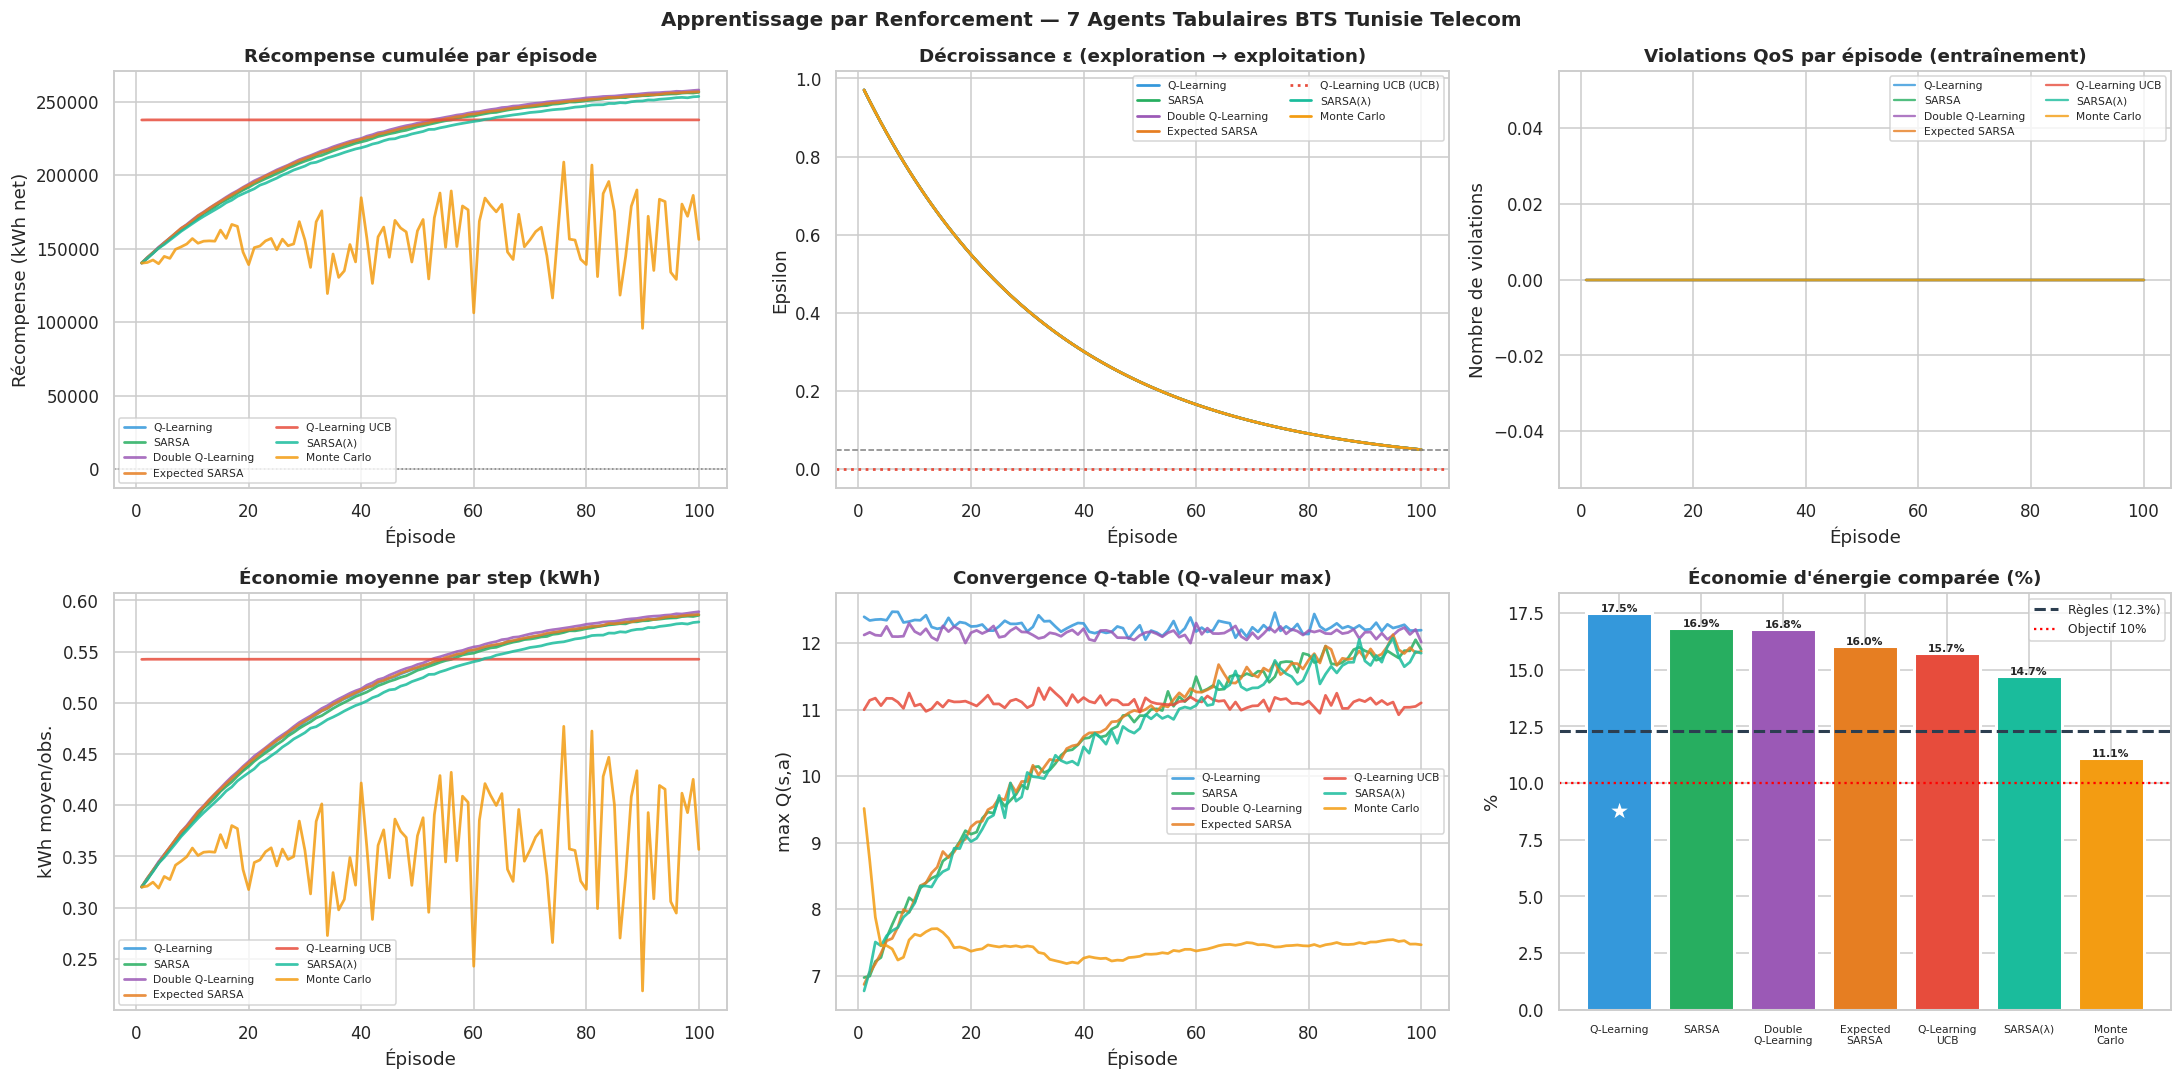

Graphique 1 sauvegardé : outputs/rl_7agents_apprentissage.png


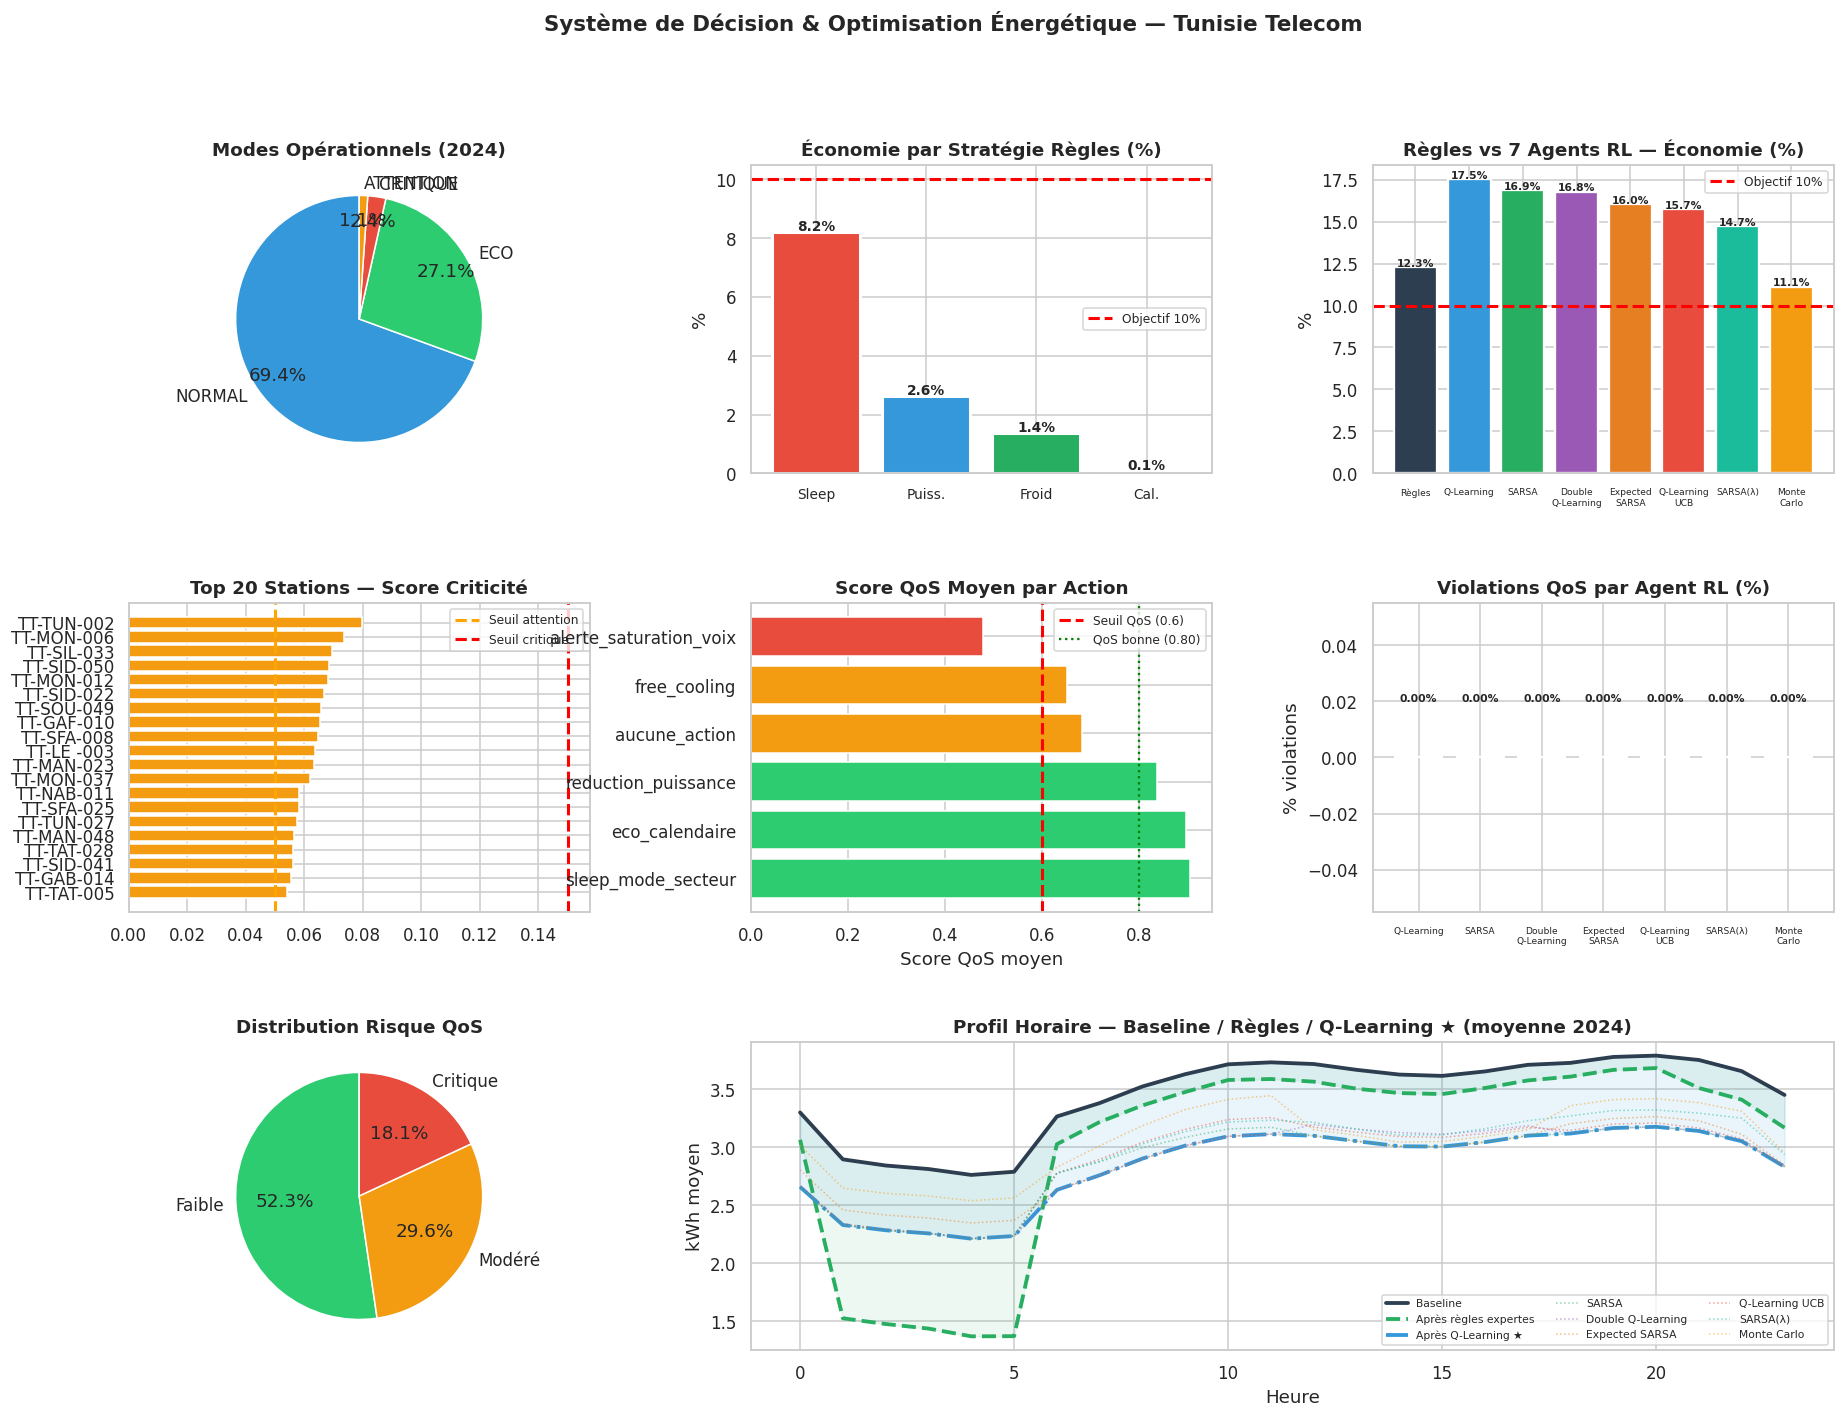

Graphique 2 sauvegardé : outputs/tableau_de_bord_complet.png


In [10]:
# Cellule 4 — Visualisations complètes (stratégies + 7 agents RL)

COLORS_RL = {
    'Q-Learning'        : '#3498db',
    'SARSA'             : '#27ae60',
    'Double Q-Learning' : '#9b59b6',
    'Expected SARSA'    : '#e67e22',
    'Q-Learning UCB'    : '#e74c3c',
    'SARSA(λ)'          : '#1abc9c',
    'Monte Carlo'       : '#f39c12',
}

episodes = range(1, N_EPISODES + 1)

# ── Figure 1 : Courbes d'apprentissage ────────────────────────────────────────
fig1, axes = plt.subplots(2, 3, figsize=(20, 10))
fig1.suptitle('Apprentissage par Renforcement — 7 Agents Tabulaires BTS Tunisie Telecom',
              fontsize=13, fontweight='bold')

# 1a. Récompense cumulée
ax = axes[0, 0]
for name, ag in agents_trained.items():
    ax.plot(episodes, ag.hist_rewards, color=COLORS_RL[name], lw=1.8, label=name, alpha=0.85)
ax.set_title('Récompense cumulée par épisode', fontweight='bold')
ax.set_xlabel('Épisode'); ax.set_ylabel('Récompense (kWh net)')
ax.legend(fontsize=7, ncol=2)
ax.axhline(0, color='gray', ls=':', lw=1)

# 1b. Décroissance epsilon
ax = axes[0, 1]
for name, ag in agents_trained.items():
    if name == 'Q-Learning UCB':
        ax.axhline(0, color=COLORS_RL[name], lw=1.8, ls=':', label=f'{name} (UCB)')
    else:
        ax.plot(episodes, ag.hist_epsilon, color=COLORS_RL[name], lw=1.8, label=name)
ax.set_title('Décroissance ε (exploration → exploitation)', fontweight='bold')
ax.set_xlabel('Épisode'); ax.set_ylabel('Epsilon')
ax.legend(fontsize=7, ncol=2)
ax.axhline(EPS_MIN, color='gray', ls='--', lw=1, label=f'ε_min={EPS_MIN}')

# 1c. Violations QoS par épisode
ax = axes[0, 2]
for name, ag in agents_trained.items():
    ax.plot(episodes, ag.hist_violations, color=COLORS_RL[name], lw=1.5, label=name, alpha=0.80)
ax.set_title('Violations QoS par épisode (entraînement)', fontweight='bold')
ax.set_xlabel('Épisode'); ax.set_ylabel('Nombre de violations')
ax.legend(fontsize=7, ncol=2)

# 1d. Économie moyenne par step
ax = axes[1, 0]
for name, ag in agents_trained.items():
    ax.plot(episodes, ag.hist_eco_moy, color=COLORS_RL[name], lw=1.8, label=name, alpha=0.85)
ax.set_title('Économie moyenne par step (kWh)', fontweight='bold')
ax.set_xlabel('Épisode'); ax.set_ylabel('kWh moyen/obs.')
ax.legend(fontsize=7, ncol=2)

# 1e. Convergence Q-table (Q-max moyen)
ax = axes[1, 1]
for name, ag in agents_trained.items():
    ax.plot(episodes, ag.hist_q_max, color=COLORS_RL[name], lw=1.8, label=name, alpha=0.85)
ax.set_title('Convergence Q-table (Q-valeur max)', fontweight='bold')
ax.set_xlabel('Épisode'); ax.set_ylabel('max Q(s,a)')
ax.legend(fontsize=7, ncol=2)

# 1f. Comparaison finale économies (barres)
ax = axes[1, 2]
noms    = list(rl_results.keys())
pcts    = [rl_results[n]['eco_pct'] for n in noms]
colors_ = [COLORS_RL[n] for n in noms]
bars    = ax.bar(range(len(noms)), pcts, color=colors_, edgecolor='white', lw=2)
ax.axhline(eco_regles_pct, color='#2c3e50', ls='--', lw=2, label=f'Règles ({eco_regles_pct:.1f}%)')
ax.axhline(10, color='red', ls=':', lw=1.5, label='Objectif 10%')
for bar, val, name in zip(bars, pcts, noms):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.05,
            f'{val:.1f}%', ha='center', fontsize=7, fontweight='bold')
    if name == best_name:
        ax.text(bar.get_x() + bar.get_width()/2, val / 2, '★',
                ha='center', va='center', fontsize=14, color='white')
ax.set_xticks(range(len(noms)))
ax.set_xticklabels([n.replace(' ', '\n') for n in noms], fontsize=7)
ax.set_title('Économie d\'énergie comparée (%)', fontweight='bold')
ax.set_ylabel('%'); ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('outputs/rl_7agents_apprentissage.png', dpi=110, bbox_inches='tight')
plt.show()
print('Graphique 1 sauvegardé : outputs/rl_7agents_apprentissage.png')

# ── Figure 2 : Tableau de bord complet ───────────────────────────────────────
fig2 = plt.figure(figsize=(20, 14))
gs   = gridspec.GridSpec(3, 3, figure=fig2, hspace=0.42, wspace=0.35)
fig2.suptitle('Système de Décision & Optimisation Énergétique — Tunisie Telecom',
              fontsize=14, fontweight='bold')

# 2a. Modes opérationnels
ax1 = fig2.add_subplot(gs[0, 0])
mode_counts = df_2024['mode_operation'].value_counts()
colors_mode = [MoteurDecisionEnergie.MODES.get(m, {}).get('couleur', 'gray') for m in mode_counts.index]
ax1.pie(mode_counts.values, labels=mode_counts.index, colors=colors_mode,
        autopct='%1.1f%%', startangle=90, pctdistance=0.8)
ax1.set_title('Modes Opérationnels (2024)', fontweight='bold')

# 2b. Économies par stratégie règles expertes
ax2 = fig2.add_subplot(gs[0, 1])
strat_noms = [n for n in economies
              if isinstance(economies[n], dict) and 'economie_pct' in economies[n]
              and 'Combinée' not in n and 'Alerte' not in n]
strat_pcts = [economies[n]['economie_pct'] for n in strat_noms]
colors_s   = ['#e74c3c', '#3498db', '#27ae60', '#f39c12']
bars2 = ax2.bar(range(len(strat_noms)), strat_pcts, color=colors_s[:len(strat_noms)],
                edgecolor='white', lw=2)
ax2.axhline(10, color='red', ls='--', lw=2, label='Objectif 10%')
for bar, val in zip(bars2, strat_pcts):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
             f'{val:.1f}%', ha='center', fontweight='bold', fontsize=9)
ax2.set_xticks(range(len(strat_noms)))
ax2.set_xticklabels(['Sleep', 'Puiss.', 'Froid', 'Cal.'], fontsize=9)
ax2.set_title('Économie par Stratégie Règles (%)', fontweight='bold')
ax2.set_ylabel('%'); ax2.legend(fontsize=8)

# 2c. Comparaison règles vs 7 agents RL
ax3 = fig2.add_subplot(gs[0, 2])
all_names = ['Règles'] + list(rl_results.keys())
all_pcts  = [eco_regles_pct] + [rl_results[n]['eco_pct'] for n in rl_results]
all_cols  = ['#2c3e50'] + [COLORS_RL[n] for n in rl_results]
bars3 = ax3.bar(range(len(all_names)), all_pcts, color=all_cols, edgecolor='white', lw=1.5)
ax3.axhline(10, color='red', ls='--', lw=2, label='Objectif 10%')
for bar, val in zip(bars3, all_pcts):
    ax3.text(bar.get_x() + bar.get_width()/2, val + 0.05,
             f'{val:.1f}%', ha='center', fontsize=7, fontweight='bold')
ax3.set_xticks(range(len(all_names)))
ax3.set_xticklabels([n.replace(' ', '\n') for n in all_names], fontsize=6)
ax3.set_title('Règles vs 7 Agents RL — Économie (%)', fontweight='bold')
ax3.set_ylabel('%'); ax3.legend(fontsize=8)

# 2d. Score criticité stations (top 20)
ax4 = fig2.add_subplot(gs[1, 0])
top20 = score_stations.sort_values('score_criticite', ascending=False).head(20)
colors_cr = ['#e74c3c' if s >= 0.15 else '#f39c12' if s >= 0.05 else '#2ecc71'
             for s in top20['score_criticite']]
ax4.barh(top20['station_id'][::-1], top20['score_criticite'][::-1], color=colors_cr[::-1])
ax4.axvline(0.05, color='orange', ls='--', lw=2, label='Seuil attention')
ax4.axvline(0.15, color='red',    ls='--', lw=2, label='Seuil critique')
ax4.set_title('Top 20 Stations — Score Criticité', fontweight='bold')
ax4.legend(fontsize=8)

# 2e. Score QoS moyen par action
ax5 = fig2.add_subplot(gs[1, 1])
if 'score_qos' in df_2024.columns:
    qos_par_action = df_2024.groupby('action_proposee')['score_qos'].mean().sort_values(ascending=False)
    colors_qa = ['#e74c3c' if v < qos_seuil else '#2ecc71' if v >= 0.80 else '#f39c12'
                 for v in qos_par_action.values]
    ax5.barh(qos_par_action.index, qos_par_action.values, color=colors_qa)
    ax5.axvline(qos_seuil, color='red',   ls='--', lw=2, label=f'Seuil QoS ({qos_seuil})')
    ax5.axvline(0.80,      color='green', ls=':',  lw=1.5, label='QoS bonne (0.80)')
    ax5.set_title('Score QoS Moyen par Action', fontweight='bold')
    ax5.set_xlabel('Score QoS moyen'); ax5.legend(fontsize=8)

# 2f. Violations QoS — radar des 7 agents
ax6 = fig2.add_subplot(gs[1, 2])
viol_pcts = [rl_results[n]['pct_viols'] for n in rl_results]
ax6.bar(range(len(rl_results)), viol_pcts,
        color=[COLORS_RL[n] for n in rl_results], edgecolor='white', lw=1.5)
for i, (name, val) in enumerate(zip(rl_results.keys(), viol_pcts)):
    ax6.text(i, val + 0.02, f'{val:.2f}%', ha='center', fontsize=7, fontweight='bold')
ax6.set_xticks(range(len(rl_results)))
ax6.set_xticklabels([n.replace(' ', '\n') for n in rl_results], fontsize=6)
ax6.set_title('Violations QoS par Agent RL (%)', fontweight='bold')
ax6.set_ylabel('% violations')

# 2g. Risque QoS
ax7 = fig2.add_subplot(gs[2, 0])
risque_counts = df_2024['risque_qos'].value_counts()
colors_r = {'Faible': '#2ecc71', 'Modéré': '#f39c12', 'Critique': '#e74c3c'}
ax7.pie(risque_counts.values, labels=risque_counts.index,
        colors=[colors_r.get(k, 'gray') for k in risque_counts.index],
        autopct='%1.1f%%', startangle=90)
ax7.set_title('Distribution Risque QoS', fontweight='bold')

# 2h. Profil horaire : baseline / règles / meilleur RL
ax8 = fig2.add_subplot(gs[2, 1:])
baseline_h  = df_2024.groupby('heure')['consommation_kwh'].mean()
eco_h       = df_2024.groupby('heure')['economie_estimee_kwh'].mean()
eco_rl_h    = df_2024.groupby('heure')['economie_rl_kwh'].mean()
conso_opt_h = baseline_h - eco_h
conso_rl_h  = baseline_h - eco_rl_h

ax8.plot(baseline_h.index, baseline_h.values, color='#2c3e50', lw=2.5, label='Baseline')
ax8.plot(conso_opt_h.index, conso_opt_h.values, color='#27ae60', lw=2.5, ls='--', label='Après règles expertes')
ax8.plot(conso_rl_h.index, conso_rl_h.values, color=COLORS_RL[best_name], lw=2.5, ls='-.', label=f'Après {best_name} ★')

# Autres agents en transparence
for name, r in rl_results.items():
    if name == best_name: continue
    col = f'eco_rl_{name.lower().replace(" ","_").replace("(","").replace(")","").replace("λ","lam")}_kwh'
    if col in df_2024.columns:
        eco_n_h = df_2024.groupby('heure')[col].mean()
        ax8.plot(eco_n_h.index, (baseline_h - eco_n_h).values,
                 color=COLORS_RL[name], lw=1, ls=':', alpha=0.5, label=name)

ax8.fill_between(range(24), conso_opt_h.values, baseline_h.values, alpha=0.08, color='#27ae60')
ax8.fill_between(range(24), conso_rl_h.values, baseline_h.values, alpha=0.10, color=COLORS_RL[best_name])
ax8.set_title(f'Profil Horaire — Baseline / Règles / {best_name} ★ (moyenne 2026)', fontweight='bold')
ax8.set_xlabel('Heure'); ax8.set_ylabel('kWh moyen')
ax8.legend(fontsize=7, ncol=3)

plt.tight_layout()
plt.savefig('outputs/tableau_de_bord_complet.png', dpi=110, bbox_inches='tight')
plt.show()
print('Graphique 2 sauvegardé : outputs/tableau_de_bord_complet.png')


In [11]:
# Cellule 5 — Pipeline d'inférence temps réel (avec meilleur agent RL intégré)

class PipelineInferenceTempsReel:
    """
    Pipeline complet d'inférence pour une mesure temps réel (station × heure).
    Intègre le meilleur agent RL en parallèle du moteur de règles.
    """

    def __init__(self, modele_lgbm, modele_anom, encodeurs, quantiles,
                 features, moteur_decision, agent_rl=None, env_rl=None):
        self.modele_lgbm   = modele_lgbm
        self.modele_anom   = modele_anom
        self.encodeurs     = encodeurs
        self.quantiles     = quantiles
        self.features      = features
        self.moteur        = moteur_decision
        self.scaler        = modele_anom['scaler_std']
        self.iso_f         = modele_anom['iso_f']
        self.anom_features = modele_anom['features']
        self.agent_rl      = agent_rl
        self.env_rl        = env_rl

    def _encoder(self, row: dict) -> dict:
        try:
            row['technologie_enc'] = int(self.encodeurs['technologie'].transform([row.get('technologie', '4G')])[0])
            row['type_zone_enc']   = int(self.encodeurs['type_zone'].transform([row.get('type_zone', 'Urbain')])[0])
        except Exception:
            row['technologie_enc'] = 0; row['type_zone_enc'] = 0
        return row

    def _enrichir(self, row: dict) -> dict:
        h = row.get('heure', 12); j = row.get('jour_semaine', 1); m = row.get('mois', 6)
        row['heure_sin'] = np.sin(2*np.pi*h/24); row['heure_cos'] = np.cos(2*np.pi*h/24)
        row['jour_sin']  = np.sin(2*np.pi*j/7);  row['jour_cos']  = np.cos(2*np.pi*j/7)
        row['mois_sin']  = np.sin(2*np.pi*m/12); row['mois_cos']  = np.cos(2*np.pi*m/12)
        row['charge_thermique']     = max(0, row.get('temperature_ambiante', 25) - 28)
        row['charge_par_secteur']   = row.get('charge_cpu_pct', 50) / max(row.get('nb_secteurs_actifs', 1), 1)
        row['efficacite_spectrale'] = (row.get('trafic_data_mbps', 1)+1) / (row.get('puissance_emission_dbm', 43)-30+1)
        row['intensite_trafic']     = row.get('nb_utilisateurs_actifs', 50) / (row.get('trafic_data_mbps', 1)+0.1)
        if 'score_qos' not in row:
            tv = row.get('taux_charge_voix', row.get('trafic_voix_erlang', 0) / 80.0)
            td = row.get('taux_charge_data', row.get('trafic_data_mbps', 0) / 100.0)
            row['score_qos'] = max(0.0, 0.50*(1-td) + 0.30*(1-tv) + 0.20*(1-row.get('charge_cpu_pct',50)/100))
        if 'optimisation_qos_autorisee' not in row:
            tv = row.get('taux_charge_voix', 0); td = row.get('taux_charge_data', 0)
            row['optimisation_qos_autorisee'] = int(row['score_qos'] >= qos_seuil and tv <= 0.80 and td <= 0.80)
        for feat in self.features:
            if feat not in row: row[feat] = 0.0
        return row

    def _action_rl(self, row: dict) -> str:
        if self.agent_rl is None or self.env_rl is None: return 'N/A'
        eps_save = self.agent_rl.epsilon
        self.agent_rl.epsilon = 0.0
        state  = self.env_rl._get_state(row)
        sq     = float(row.get('score_qos', 1.0))
        qok    = int(row.get('optimisation_qos_autorisee', 1))
        va     = get_valid_actions(sq, qok, QOS_MIN_LIST, self.env_rl.n_actions)
        action = self.agent_rl.greedy_action(state, va)
        self.agent_rl.epsilon = eps_save
        qm = self.env_rl.QOS_MIN[action]
        if qm is not None and (sq < qm or qok == 0):
            return 'aucune_action'
        return self.env_rl.ACTIONS[action]

    def predire(self, row_brut: dict) -> dict:
        t0  = time.time()
        row = self._encoder(row_brut.copy())
        row = self._enrichir(row)

        X          = np.array([[row.get(f, 0.0) for f in self.features]])
        conso_pred = float(self.modele_lgbm.predict(X)[0])
        q10        = float(self.quantiles['q10'].predict(X)[0])
        q90        = float(self.quantiles['q90'].predict(X)[0])

        X_anom = np.array([[row.get(f, 0.0) for f in self.anom_features]])
        try:
            X_anom_scaled = self.scaler.transform(X_anom)
            score_iso     = float(-self.iso_f.score_samples(X_anom_scaled)[0])
        except Exception:
            score_iso = 0.5
        score_norm = np.clip((score_iso - 0.3) / 0.4, 0, 1)
        row['anomalie_score_ensemble'] = score_norm
        row['nb_votes_anomalie']       = int(score_norm > 0.5) * 3

        conso_reel      = row_brut.get('consommation_kwh', conso_pred)
        hors_intervalle = not (q10 <= conso_reel <= q90)
        decision        = self.moteur.decider_mode(pd.Series(row))
        score_qos       = float(row.get('score_qos', 1.0))
        type_anomalie   = ('prioritaire' if hors_intervalle and score_qos < qos_seuil
                           else 'energetique_pure' if hors_intervalle else 'normale')

        return {
            'timestamp'                 : datetime.now().isoformat(),
            'station_id'                : row_brut.get('station_id', 'INCONNUE'),
            'conso_predite_kwh'         : round(conso_pred, 4),
            'intervalle_q10'            : round(q10, 4),
            'intervalle_q90'            : round(q90, 4),
            'hors_intervalle'           : hors_intervalle,
            'score_anomalie'            : round(score_norm, 4),
            'type_anomalie'             : type_anomalie,
            'mode_operation'            : decision['mode'],
            'action_proposee_regles'    : decision['action_principale'],
            'action_proposee_rl'        : self._action_rl(row),
            'agent_rl_utilise'          : best_name,
            'economie_kwh_estimee'      : round(decision['eco_potentiel_pct'] / 100 * conso_pred, 4),
            'score_qos'                 : round(score_qos, 4),
            'risque_qos'                : decision['risque_qos'],
            'optimisation_qos_autorisee': int(row.get('optimisation_qos_autorisee', 1)),
            'latence_ms'                : round((time.time()-t0)*1000, 2),
        }


pipeline = PipelineInferenceTempsReel(
    modele_lgbm=modele_lgbm, modele_anom=modele_anom, encodeurs=encodeurs,
    quantiles=quantiles, features=FEATURES, moteur_decision=moteur,
    agent_rl=best_agent, env_rl=env,
)

print(f'Pipeline d\'inférence instancié (agent RL : {best_name})')
print('\nSIMULATION — 5 INFÉRENCES TEMPS RÉEL\n')

exemples = [
    {'station_id': 'TT-TUN-012', 'heure': 3,  'mois': 7, 'jour_semaine': 1,
     'technologie': '4G+', 'type_zone': 'Urbain', 'charge_cpu_pct': 20,
     'trafic_data_mbps': 5, 'temperature_ambiante': 32, 'nb_utilisateurs_actifs': 10,
     'puissance_emission_dbm': 43, 'nb_secteurs_actifs': 3, 'trafic_voix_erlang': 2,
     'taux_charge_voix': 0.03, 'taux_charge_data': 0.03, 'score_qos': 0.87,
     'optimisation_qos_autorisee': 1, 'est_weekend': 0, 'est_ferie': 0,
     'consommation_kwh': 3.5, 'conso_moy_24h': 4.0, 'conso_moy_7j': 4.1, 'eei': 95},
    {'station_id': 'TT-GAB-005', 'heure': 14, 'mois': 7, 'jour_semaine': 4,
     'technologie': '4G',  'type_zone': 'Urbain', 'charge_cpu_pct': 88,
     'trafic_data_mbps': 95, 'temperature_ambiante': 38, 'nb_utilisateurs_actifs': 420,
     'puissance_emission_dbm': 46, 'nb_secteurs_actifs': 6, 'trafic_voix_erlang': 45,
     'taux_charge_voix': 0.56, 'taux_charge_data': 0.95, 'score_qos': 0.38,
     'optimisation_qos_autorisee': 0, 'est_weekend': 0, 'est_ferie': 0,
     'consommation_kwh': 12.8, 'conso_moy_24h': 8.5, 'conso_moy_7j': 8.0, 'eei': 165},
    {'station_id': 'TT-SFA-001', 'heure': 2,  'mois': 5, 'jour_semaine': 3,
     'technologie': '4G',  'type_zone': 'Periurbain', 'charge_cpu_pct': 15,
     'trafic_data_mbps': 3, 'temperature_ambiante': 12, 'nb_utilisateurs_actifs': 8,
     'puissance_emission_dbm': 42, 'nb_secteurs_actifs': 4, 'trafic_voix_erlang': 1,
     'taux_charge_voix': 0.01, 'taux_charge_data': 0.03, 'score_qos': 0.73,
     'optimisation_qos_autorisee': 1, 'est_weekend': 0, 'est_ferie': 0,
     'consommation_kwh': 3.2, 'conso_moy_24h': 3.5, 'conso_moy_7j': 3.6, 'eei': 88},
    {'station_id': 'TT-BIS-003', 'heure': 3,  'mois': 1, 'jour_semaine': 6,
     'technologie': '4G+', 'type_zone': 'Urbain', 'charge_cpu_pct': 18,
     'trafic_data_mbps': 2, 'temperature_ambiante': 11, 'nb_utilisateurs_actifs': 6,
     'puissance_emission_dbm': 41, 'nb_secteurs_actifs': 3, 'trafic_voix_erlang': 1,
     'taux_charge_voix': 0.01, 'taux_charge_data': 0.01, 'score_qos': 0.91,
     'optimisation_qos_autorisee': 1, 'est_weekend': 1, 'est_ferie': 0,
     'consommation_kwh': 4.1, 'conso_moy_24h': 4.3, 'conso_moy_7j': 4.2, 'eei': 89,
     'vitesse_vent_ms': 5.0, 'humidite_relative_pct': 60, 'efficacite_free_cooling': 0.65},
    {'station_id': 'TT-KAI-009', 'heure': 11, 'mois': 8, 'jour_semaine': 2,
     'technologie': '2G',  'type_zone': 'Rural', 'charge_cpu_pct': 72,
     'trafic_data_mbps': 0.2, 'temperature_ambiante': 38, 'nb_utilisateurs_actifs': 110,
     'puissance_emission_dbm': 43, 'nb_secteurs_actifs': 2, 'trafic_voix_erlang': 28,
     'taux_charge_voix': 0.93, 'taux_charge_data': 0.40, 'score_qos': 0.35,
     'optimisation_qos_autorisee': 0, 'est_weekend': 0, 'est_ferie': 0,
     'consommation_kwh': 2.1, 'conso_moy_24h': 2.0, 'conso_moy_7j': 2.0, 'eei': 140},
]

print(f'{"Station":<14} {"QoS":>6} {"Risque":>8} {"Mode":<10} {"Action Règles":<28} {"Action RL":<28} {"Lat ms":>7}')
print('-' * 108)
resultats_sim = []
for ex in exemples:
    res = pipeline.predire(ex)
    resultats_sim.append(res)
    print(f"{res['station_id']:<14} "
          f"{res['score_qos']:>6.3f} "
          f"{res['risque_qos']:>8s} "
          f"{res['mode_operation']:<10} "
          f"{res['action_proposee_regles'][:26]:<28} "
          f"{res['action_proposee_rl'][:26]:<28} "
          f"{res['latence_ms']:>7.1f}")
print()
print(f'Latence moyenne : {np.mean([r["latence_ms"] for r in resultats_sim]):.1f} ms')
print(f'Agent RL utilisé : {best_name}')


Pipeline d'inférence instancié (agent RL : Q-Learning)

SIMULATION — 5 INFÉRENCES TEMPS RÉEL

Station           QoS   Risque Mode       Action Règles                Action RL                     Lat ms
------------------------------------------------------------------------------------------------------------
TT-TUN-012      0.870   Faible ECO        Activer Sleep Mode sur sec   sleep_mode_secteur              93.3
TT-GAB-005      0.380 Critique CRITIQUE   ALERTE IMMEDIATE — Interve   free_cooling                    62.1
TT-SFA-001      0.730   Modéré ECO        Activer Sleep Mode sur sec   free_cooling                    38.6
TT-BIS-003      0.910   Faible ECO        Activer Sleep Mode sur sec   sleep_mode_secteur              41.5
TT-KAI-009      0.350 Critique NORMAL     Monitoring standard toutes   free_cooling                    43.1

Latence moyenne : 55.7 ms
Agent RL utilisé : Q-Learning


In [12]:
# Cellule 6 — Données Streamlit (avec KPIs des 7 agents RL)

print('Préparation des données optimisées pour le dashboard Streamlit...')

nom_comb = '5 — Combinée (1+2+3+4)'
kpi_reseau = {
    'nb_stations'                : int(df_2024['station_id'].nunique()),
    'nb_mesures'                 : int(len(df_2024)),
    'conso_totale_kwh'           : round(df_2024['consommation_kwh'].sum(), 2),
    'conso_moyenne_kwh'          : round(df_2024['consommation_kwh'].mean(), 4),
    'eei_moyen'                  : round(df_2024['eei'].mean(), 2),
    'score_qos_moyen'            : round(df_2024['score_qos'].mean(), 4) if 'score_qos' in df_2024.columns else None,
    'pct_mode_eco'               : round((df_2024['mode_operation'] == 'ECO').mean() * 100, 2),
    'pct_mode_critique'          : round((df_2024['mode_operation'] == 'CRITIQUE').mean() * 100, 2),
    'pct_anomalies'              : round(df_2024['label_ensemble_score'].mean() * 100, 2),
    'n_alertes_2g'               : int((df_2024['action_proposee'] == 'alerte_saturation_voix').sum()),
    'economie_combinee_pct'      : round(economies.get(nom_comb, {}).get('economie_pct', 0), 2),
    'economie_combinee_kwh'      : round(economies.get(nom_comb, {}).get('economie_kwh', 0), 0),
    'co2_evite_t'                : round(economies.get(nom_comb, {}).get('co2_evite_t', 0), 1),
    'economie_dt'                : round(economies.get(nom_comb, {}).get('economie_dt', 0), 0),
    # KPIs meilleur agent RL
    'meilleur_agent_rl'          : best_name,
    'economie_rl_pct'            : round(eco_rl_pct, 2),
    'economie_rl_kwh'            : round(eco_rl_kwh, 0),
    'rl_violations_qos'          : n_violations,
    # KPIs tous les agents
    'rl_agents_comparaison'      : {n: {'eco_pct': round(r['eco_pct'],2), 'n_viols': r['n_viols']}
                                    for n, r in rl_results.items()},
    'generated_at'               : datetime.now().isoformat(),
}

profil_horaire = df_2024.groupby('heure').agg(
    conso_moy       = ('consommation_kwh',       'mean'),
    economie_moy    = ('economie_estimee_kwh',   'mean'),
    economie_rl_moy = ('economie_rl_kwh',        'mean'),
    score_qos_moy   = ('score_qos',              'mean') if 'score_qos' in df_2024.columns else ('label_ensemble_score', 'count'),
    score_anom_moy  = ('anomalie_score_ensemble', 'mean'),
    pct_eco         = ('mode_operation',          lambda x: (x == 'ECO').mean() * 100),
    pct_critique    = ('mode_operation',          lambda x: (x == 'CRITIQUE').mean() * 100),
).reset_index()
profil_horaire['conso_optimisee_moy']    = profil_horaire['conso_moy'] - profil_horaire['economie_moy']
profil_horaire['conso_optimisee_rl_moy'] = profil_horaire['conso_moy'] - profil_horaire['economie_rl_moy']

agg_carte = {
    'conso_moy'       : ('consommation_kwh',       'mean'),
    'eei_moy'         : ('eei',                    'mean'),
    'score_anom_moy'  : ('anomalie_score_ensemble', 'mean'),
    'economie_tot_kwh': ('economie_estimee_kwh',   'sum'),
    'economie_rl_kwh' : ('economie_rl_kwh',        'sum'),
    'nb_anomalies'    : ('label_ensemble_score',   'sum'),
    'gouvernorat'     : ('gouvernorat',            'first'),
    'type_zone'       : ('type_zone',              'first'),
    'technologie'     : ('technologie',            'first'),
}
if 'score_qos' in df_2024.columns:
    agg_carte['score_qos_moy'] = ('score_qos', 'mean')
carte_stations = df_2024.groupby('station_id').agg(**agg_carte).reset_index()
carte_stations = carte_stations.merge(
    score_stations[['station_id', 'score_criticite', 'categorie']],
    on='station_id', how='left'
)

ts_data = df_2024.groupby(['timestamp', 'annee', 'mois', 'heure']).agg(
    conso_tot       = ('consommation_kwh',     'sum'),
    economie_tot    = ('economie_estimee_kwh', 'sum'),
    economie_rl_tot = ('economie_rl_kwh',      'sum'),
    nb_anomalies    = ('label_ensemble_score', 'sum'),
    mode_majoritaire= ('mode_operation',       lambda x: x.value_counts().index[0]),
).reset_index()

profil_horaire.to_parquet('outputs/streamlit_profil_horaire.parquet', index=False)
carte_stations.to_parquet('outputs/streamlit_carte_stations.parquet', index=False)
ts_data.to_parquet('outputs/streamlit_timeseries.parquet', index=False)
score_stations.to_parquet('outputs/streamlit_score_stations.parquet', index=False)
df_2024.to_parquet('outputs/streamlit_data.parquet', index=False)

with open('outputs/kpi_reseau.json', 'w', encoding='utf-8') as f:
    json.dump(kpi_reseau, f, indent=2, ensure_ascii=False, default=str)

print('Données Streamlit préparées.')
for k, v in kpi_reseau.items():
    if k not in ('generated_at', 'rl_agents_comparaison'):
        print(f'  {k:<42} : {v}')
print('  rl_agents_comparaison :')
for nm, d in kpi_reseau['rl_agents_comparaison'].items():
    print(f'    {nm:<22} : éco={d["eco_pct"]}% | viols={d["n_viols"]:,}')


Préparation des données optimisées pour le dashboard Streamlit...
Données Streamlit préparées.
  nb_stations                                : 50
  nb_mesures                                 : 438050
  conso_totale_kwh                           : 1511130.38
  conso_moyenne_kwh                          : 3.4497
  eei_moyen                                  : 101.08
  score_qos_moyen                            : 0.7456
  pct_mode_eco                               : 27.09
  pct_mode_critique                          : 2.36
  pct_anomalies                              : 4.29
  n_alertes_2g                               : 11653
  economie_combinee_pct                      : 12.28
  economie_combinee_kwh                      : 185569.0
  co2_evite_t                                : 98.4
  economie_dt                                : 74228.0
  meilleur_agent_rl                          : Q-Learning
  economie_rl_pct                            : 17.52
  economie_rl_kwh                           

In [13]:
# Cellule 7 — Sauvegarde de tous les artefacts

def make_json_serializable(obj):
    if isinstance(obj, dict):   return {k: make_json_serializable(v) for k, v in obj.items()}
    if isinstance(obj, list):   return [make_json_serializable(v) for v in obj]
    if isinstance(obj, np.bool_):    return bool(obj)
    if isinstance(obj, np.integer):  return int(obj)
    if isinstance(obj, np.floating): return float(obj)
    return obj

# ── Sauvegarder tous les agents RL ───────────────────────────────────────────
agents_save = {}
for name, agent in agents_trained.items():
    r = rl_results[name]
    q_dict = {}
    if isinstance(agent, AgentDoubleQLearning):
        for s in set(agent.Q1.keys()) | set(agent.Q2.keys()):
            q_dict[str(s)] = ((agent.Q1[s] + agent.Q2[s]) / 2).tolist()
    else:
        for s, v in agent.Q.items():
            q_dict[str(s)] = v.tolist()
    agents_save[name] = {
        'Q_table'    : q_dict,
        'class_name' : type(agent).__name__,
        'reference'  : agent.REF,
        'hyperparams': {'alpha': getattr(agent,'alpha',None),
                        'gamma': getattr(agent,'gamma',None),
                        'lam'  : getattr(agent,'lam',None),
                        'c'    : getattr(agent,'c',None),
                        'n_episodes': N_EPISODES},
        'metriques'  : {'eco_pct': round(r['eco_pct'],4), 'eco_kwh': round(r['eco_kwh'],2),
                        'n_violations': r['n_viols'], 'is_best': name == best_name},
    }

with open('outputs/agents_rl_7.pkl', 'wb') as f:
    pickle.dump(agents_save, f)

# ── Pipeline complet ─────────────────────────────────────────────────────────
joblib.dump({
    'moteur'         : moteur,
    'strategie'      : strat,
    'modele_lgbm'    : modele_lgbm,
    'modele_stack'   : modele_stack,
    'modele_anom'    : modele_anom,
    'encodeurs'      : encodeurs,
    'quantiles'      : quantiles,
    'config'         : config,
    'qos_seuil'      : qos_seuil,
    'best_agent_name': best_name,
    'env_rl_meta'    : {
        'actions'     : make_json_serializable(env.ACTIONS),
        'eco_fraction': make_json_serializable(env.ECO_FRACTION),
        'qos_min'     : make_json_serializable(
                            {k: (v if v is not None else None)
                             for k, v in env.QOS_MIN.items()}
                        ),
    },
}, 'outputs/pipeline_inference.joblib', compress=3)

# ── Décisions par station × heure ─────────────────────────────────────────────
agg_dec = {
    'mode_majoritaire'    : ('mode_operation',          lambda x: x.value_counts().index[0]),
    'action_proposee'     : ('action_proposee',          lambda x: x.value_counts().index[0]),
    'action_rl'           : ('action_rl',               lambda x: x.value_counts().index[0]),
    'economie_kwh_estimee': ('economie_estimee_kwh',    'sum'),
    'economie_rl_kwh'     : ('economie_rl_kwh',         'sum'),
    'score_anom_moy'      : ('anomalie_score_ensemble', 'mean'),
    'conso_moy'           : ('consommation_kwh',        'mean'),
}
if 'score_qos' in df_2024.columns:
    agg_dec['score_qos_moy'] = ('score_qos', 'mean')
    agg_dec['risque_qos']    = ('risque_qos', lambda x: x.value_counts().index[0])
decisions_station = df_2024.groupby(['station_id', 'heure']).agg(**agg_dec).reset_index()
decisions_station.to_parquet('outputs/decisions_par_station.parquet', index=False)

# ── Rapport JSON ──────────────────────────────────────────────────────────────
rapport = {
    'economies'    : make_json_serializable(economies),
    'kpi_reseau'   : make_json_serializable(kpi_reseau),
    'couvertures'  : {
        'strat_1_sleep_pct'         : round(strat.couverture_1 * 100, 1),
        'strat_2_reduction_pct'     : round(strat.couverture_2 * 100, 1),
        'strat_3_free_cooling_pct'  : round(strat.couverture_3 * 100, 1),
        'strat_4_eco_calendaire_pct': round(strat.couverture_4 * 100, 1),
        'strat_5_alerte_2g_pct'     : round(strat.couverture_5 * 100, 1),
    },
    'rl_resultats_tous_agents': {
        name: {
            'economie_pct'  : round(r['eco_pct'],   4),
            'economie_kwh'  : round(r['eco_kwh'],   2),
            'n_violations'  : r['n_viols'],
            'pct_violations': round(r['pct_viols'], 4),
            'class_name'    : type(r['agent']).__name__,
            'reference'     : r['agent'].REF,
            'is_best'       : name == best_name,
        }
        for name, r in rl_results.items()
    },
    'meilleur_agent'       : best_name,
    'top_eco_agent'        : top_eco_name,
    'n_episodes'           : N_EPISODES,
    'generated_at'         : datetime.now().isoformat(),
}
with open('outputs/rapport_optimisation.json', 'w', encoding='utf-8') as f:
    json.dump(rapport, f, indent=2, ensure_ascii=False, default=str)

# ── Résumé final ──────────────────────────────────────────────────────────────
artefacts = [
    ('pipeline_inference.joblib',        'Pipeline d\'inférence complet'),
    ('agents_rl_7.pkl',                  '[RL] 7 agents Q-Table sérialisés'),
    ('decisions_par_station.parquet',    'Décisions par station × heure'),
    ('rapport_optimisation.json',        'Rapport économies & KPI & 7 agents RL'),
    ('kpi_reseau.json',                  'KPI réseau globaux'),
    ('streamlit_data.parquet',           'Dataset complet Streamlit'),
    ('streamlit_profil_horaire.parquet', 'Profils horaires'),
    ('streamlit_carte_stations.parquet', 'Données carte par station'),
    ('streamlit_timeseries.parquet',     'Séries temporelles agrégées'),
    ('streamlit_score_stations.parquet', 'Scores criticité par station'),
    ('rl_7agents_apprentissage.png',     '[RL] Courbes d\'apprentissage 7 agents'),
    ('tableau_de_bord_complet.png',      'Tableau de bord complet'),
]

print('Toutes les sorties du Notebook 3 sauvegardées :')
for fichier, desc in artefacts:
    print(f'   outputs/{fichier:<48} — {desc}')

print()
print('PIPELINE COMPLET TERMINÉ')
print(f'  Économies Règles Expertes         : {eco_regles_pct:.2f}%')
print(f'  Meilleur agent RL ({best_name:<16}): {eco_rl_pct:.2f}%')
print()
print('  Classement des 7 agents RL (économie %) :')
for i, (n, r) in enumerate(sorted(rl_results.items(), key=lambda x: -x[1]['eco_pct']), 1):
    star = ' ★' if n == best_name else '  '
    print(f'    {i}. {n+star:<26} {r["eco_pct"]:.2f}% | {r["n_viols"]:,} violations')
print()
print('Dashboard Streamlit : streamlit run app.py')


Toutes les sorties du Notebook 3 sauvegardées :
   outputs/pipeline_inference.joblib                        — Pipeline d'inférence complet
   outputs/agents_rl_7.pkl                                  — [RL] 7 agents Q-Table sérialisés
   outputs/decisions_par_station.parquet                    — Décisions par station × heure
   outputs/rapport_optimisation.json                        — Rapport économies & KPI & 7 agents RL
   outputs/kpi_reseau.json                                  — KPI réseau globaux
   outputs/streamlit_data.parquet                           — Dataset complet Streamlit
   outputs/streamlit_profil_horaire.parquet                 — Profils horaires
   outputs/streamlit_carte_stations.parquet                 — Données carte par station
   outputs/streamlit_timeseries.parquet                     — Séries temporelles agrégées
   outputs/streamlit_score_stations.parquet                 — Scores criticité par station
   outputs/rl_7agents_apprentissage.png                  